<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Modelling" data-toc-modified-id="Modelling-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Modelling</a></span><ul class="toc-item"><li><span><a href="#ADF,-KPSS-test" data-toc-modified-id="ADF,-KPSS-test-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>ADF, KPSS test</a></span></li><li><span><a href="#ACF-and-PACF" data-toc-modified-id="ACF-and-PACF-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>ACF and PACF</a></span></li></ul></li><li><span><a href="#Functions" data-toc-modified-id="Functions-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Functions</a></span><ul class="toc-item"><li><span><a href="#Changing-train-data---forecast-5-days" data-toc-modified-id="Changing-train-data---forecast-5-days-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Changing train data - forecast 5 days</a></span></li></ul></li><li><span><a href="#Training-rolling-ARIMA-1,0,1" data-toc-modified-id="Training-rolling-ARIMA-1,0,1-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Training rolling ARIMA 1,0,1</a></span></li><li><span><a href="#Training-without-rolling-ARIMA-1,0,1" data-toc-modified-id="Training-without-rolling-ARIMA-1,0,1-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Training without rolling ARIMA 1,0,1</a></span></li><li><span><a href="#Training-ARIMA-1,1,1" data-toc-modified-id="Training-ARIMA-1,1,1-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Training ARIMA 1,1,1</a></span></li><li><span><a href="#SARIMAX-(1,-0,-1)-(1,-0,-1,-7)" data-toc-modified-id="SARIMAX-(1,-0,-1)-(1,-0,-1,-7)-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>SARIMAX (1, 0, 1) (1, 0, 1, 7)</a></span></li><li><span><a href="#SARIMAX" data-toc-modified-id="SARIMAX-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>SARIMAX</a></span></li></ul></div>

In [1]:
import requests
# import pprint
import csv
from datetime import datetime, timedelta
import logging
import os
import logging.handlers

# Data analysis
import pandas as pd
import numpy as np

# Data Visualization
# import matplotlib.pyplot as plt 
# import seaborn as sns
# import plotly.express as px 

# Time Series
# from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# from statsmodels.tsa.stattools import acf, pacf
from datetime import datetime, timedelta
from statsmodels.tsa.arima.model import ARIMA 
from statsmodels.tsa.statespace.sarimax import SARIMAX
# from pmdarima import auto_arima
# import statsmodels.api as sm

# For printing multiple outputs
# from IPython.core.interactiveshell import InteractiveShell
# InteractiveShell.ast_node_interactivity = "all"

# Visualization parameters
# sns.set(rc={"figure.dpi":100, 'savefig.dpi':300})
# sns.set_context('notebook')
# sns.set_style("ticks")
# from IPython.display import set_matplotlib_formats
# %config InlineBackend.figure_format = 'retina'

# Metrics for model evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Velachery
Velachery = "Velachery Res. Area"
Velachery_STATION = "Velachery, Chennai, India"
Velachery_OUTPUT = "../data/cron_job_data/velachery_cron_output.csv"

# alandur
alandur = "Alandur Bus Depot"
alandur_STATION = "Alandur, Chennai, India"
alandur_OUTPUT = "../static/data/alandur_cron_output.csv"
alandur_DAILY_AQI = '../static/data/alandur_daily.csv'

# Manali
Manali = "Manali Village"
Manali_STATION = "Manali, Chennai, India"
Manali_OUTPUT = "../data/cron_job_data/manali_cron_output.csv"



stations = [(Velachery,  Velachery_OUTPUT), (alandur, alandur_OUTPUT), (Manali, Manali_OUTPUT) ]

# We have selected best model based on different combinations - See Modelling block below
ORDER, SEASONAL_ORDER = (1, 0, 1), (1, 0, 1, 7)
FORECAST_alandur_DAILY_AQI = '../data/ProcessedData/FTS/forecast_alandur_daily_aqi.csv'

def get_api_token():
    return '66f8e6976ba9c150deb7dd9ae09171437ab1a304'
    
# Incase if api fails, write to file with previous day
# In 2nd cron daily job, Incase if api fails, write to file with previous day

def setData(station, output_file, logger, TOKEN):
    '''
    This function is called hourly once. 
    It fetches the real-time hourly AQI data for 4 stations and writes to the hourly csv files.
    This data is consumed by writeData function.
    '''
    
    try:
        # Get the API response
        url = "https://api.waqi.info/search/?token=" + TOKEN + "&keyword=" + station
        response = requests.get(url)
        if response.status_code == 200:
            res = response.json()
            result = []
            if station.lower() in (res["data"][0]['station']['name']).lower():
                result.append(res["data"][0]['aqi'])
                result.append(res["data"][0]['station']['name'])
                result.append(pd.to_datetime(res["data"][0]['time']['stime']))
            logger.info(f"station=> {station}, result => {result}")
            print(f"station=> {station}, result => {result}")
            
            # If AQI is not a number, dont write it and return
            try:
                int(result[0])
            except Exception as exception:
                logger.info(f"setData function - AQI is not an integer. Exception {type(exception).__name__} has occured for station=> {station}")
                return
            
            # Write to the file only when (station, time) is not already existing in the file.

            new_timestamp = (res["data"][0]['time']['stime'])
            csv_file_path = output_file

            # Check if the new timestamp is already present
            with open(csv_file_path, 'r') as csv_file:
                csv_reader = csv.reader(csv_file)
                # Assuming the timestamp is in the 3rd column
                existing_timestamps = [row[2] for row in csv_reader]

            if new_timestamp not in existing_timestamps:
                with open(csv_file_path, 'a', newline='') as csv_file:
                    csv_writer = csv.writer(csv_file)
                    csv_writer.writerow(result)
                print(f'The hourly data has been written to {csv_file_path} with Timestamp: {new_timestamp}')
                logger.info(f'The hourly data has been written to {csv_file_path} with Timestamp: {new_timestamp}')
            else:
                print(f'Timestamp {new_timestamp} already present in {csv_file_path}, not appending.')
                logger.info(f'Timestamp {new_timestamp} already present in {csv_file_path}, not appending.')
        else:
            print(f"setData function - Error: {response.status_code} - {response.text}")
            logger.info(f"setData function - Error: {response.status_code} - {response.text}")
    except Exception as e:
        print(f"setData function - Exception {type(e).__name__} has occured for station=> {station}")
        logger.info(f"setData function - Exception {type(e).__name__} has occured for station=> {station}")

def setLogger():
    '''
    This function sets the logger to the logs directory.
    Every day, a new file gets created.
    '''
    logger = logging.getLogger(__name__)
    logger.setLevel(logging.INFO)
    logger_file_handler = logging.handlers.RotatingFileHandler(
        f"logs/{datetime.now().strftime('%d-%m-%Y')}.log",
        maxBytes=1024 * 1024,
        backupCount=1,
        encoding="utf8",
    )
    formatter = logging.Formatter("%(asctime)s - %(name)s - %(levelname)s - %(message)s")
    logger_file_handler.setFormatter(formatter)
    logger.addHandler(logger_file_handler)
    return logger

def writeData(station_hourly_aqi, station_daily_aqi):
    '''
    This function is called daily once at 1 AM. 
    It preprocesses the data, computes the daily AQI from hourly AQI csv files and writes to the daily csv files.
    This data is consumed by retrain_model function.
    '''
    # Hourly data preprocessing
    df_api = pd.read_csv(station_hourly_aqi)
    df_api['Time'] = pd.to_datetime(df_api['Datetime'])
    df_api.set_index('Time', inplace=True)
    df_api = df_api['AQI'].resample('D').mean()
    df_api = pd.DataFrame(df_api)
    print(f"df_api columns {df_api.columns}")
    logger.info(f"df_api columns {df_api.columns}")
    df_api['AQI'] = round(df_api['AQI'])

    today = datetime.now().date()
    yesterday = today - timedelta(days=1)

    # Write it to the Daily data csv file
    temp_daily_aqi = pd.read_csv(station_daily_aqi)
    print(f'temp_daily_aqi columns {temp_daily_aqi.columns}')
    logger.info(f'temp_daily_aqi columns {temp_daily_aqi.columns}')
                
    temp_daily_aqi['Date'] = pd.to_datetime(temp_daily_aqi['Date'])
    temp_daily_aqi.set_index('Date', inplace=True)

    print(f"temp_daily_aqi[{yesterday}]=> {temp_daily_aqi[yesterday:yesterday]}")
    logger.info(f"temp_daily_aqi[{yesterday}]=> {temp_daily_aqi[yesterday:yesterday]}")
    
    try:
        with open(station_daily_aqi, 'a', newline='') as csv_file:
            if len(temp_daily_aqi[yesterday:yesterday]) == 0: # Write only if it does not exist already
                csv_writer = csv.writer(csv_file)
                index = temp_daily_aqi.iloc[-1,0] + 1 # Add 1 to yesterday's index
                aqi = df_api[yesterday:yesterday].AQI.values[0]
                print(f'Index => {index}, yesterday => {yesterday} & AQI => {aqi}')
                logger.info(f'Index => {index}, yesterday => {yesterday} & AQI => {aqi}')
                if np.isnan(df_api[yesterday:yesterday].AQI.values[0]): # If NaN, take yesterday's value.
                    aqi = temp_daily_aqi.iloc[-1,2]
                csv_writer.writerow([index, yesterday, aqi])
                print(f'Daily AQI data has been written to {station_daily_aqi}')
                logger.info(f'Daily AQI data has been written to {station_daily_aqi}')
    except Exception as e:
        print(f"writeData function - Exception {type(e).__name__} has occured for station=> {station_daily_aqi}")
        logger.info(f"writeData function - Exception {type(e).__name__} has occured for station=> {station_daily_aqi}")

def retrain_model(order, seasonal_order, station_daily_aqi):
    '''
    This function is called daily once at 1 AM. 
    It takes into account today's AQI and re-trains the model.
    We check the model's performance by splitting data into train & test data, then train the model and calculate MAPE.
    If MAPE is <= 30%, we consider entire data (no splitting into train & test) and re-train our model & forecast for the next 5 days.
    Else if MAPE is > 30%, an email is sent to myself (Pranay Bomma) to manually look into the model and fix it.
    '''

    # Read the data & clean it.
    daily_aqi = pd.read_csv(station_daily_aqi)
    daily_aqi['Date'] = pd.to_datetime(daily_aqi['Datetime'])
    daily_aqi.set_index('Date', inplace=True)
    daily_aqi.drop(columns=['Unnamed: 0'], inplace=True)
    daily_aqi.index = pd.to_datetime(daily_aqi.index)
    daily_aqi.ffill(inplace=True)

    df = daily_aqi
    
    # Split into train & test
    train_end = df.index[-1] - timedelta(days=5)  # Except last 5 days
    print(f"train_end=> {train_end}")
    logger.info(f'Re-training the model & train_end is {train_end}')
    
    train_data = df.loc[:train_end, 'AQI']
    test_data = df.loc[train_end + timedelta(days=1):, 'AQI']

    # Train the model
    model = SARIMAX(train_data, order=order, seasonal_order=seasonal_order)
    model_fit = model.fit()

    predictions = model_fit.forecast(len(test_data))
    predictions = pd.Series(predictions, index=test_data.index)
    
    # Calculate MAPE
    MAPE = round(mean_absolute_percentage_error(test_data, predictions) * 100, 2)  # Round it off to two decimal points
    print(f"\n\nMAPE=> {MAPE}")
    logger.info(f'Retrained the model & MAPE is {MAPE}%')

    if (MAPE <= 30):
        # If MAPE is < 30%, forecast next 5 days.
        train_data = df.loc[:, 'AQI']
        model = SARIMAX(train_data, order=order, seasonal_order=seasonal_order)
        model_fit = model.fit()
        predictions = model_fit.forecast(len(test_data))
        predictions = pd.Series(predictions)
        print(f"\n\nForecast=> {predictions}")
        logger.info(f"Forecast=> {predictions}")

        # Save the forecast
        try:
            
            containsNaN = predictions.isna().sum()
            if containsNaN == 0:
                with open(FORECAST_alandur_DAILY_AQI, 'w', newline='') as csv_file:
                    csv_writer = csv.writer(csv_file)
                    csv_writer.writerow(['Date', 'AQI'])
                    for i in range(5):
                        csv_writer.writerow([predictions.index[i].date(), round(predictions.values[i])])

                    # Log the predictions to view in future.
                    print(f'The forecast data has been written to {FORECAST_alandur_DAILY_AQI}')
                    logger.info(f'The forecast data has been written to {FORECAST_alandur_DAILY_AQI}')
            else:
                print(f'retrain_model function - The forecast data has NaNs.')
                logger.info(f'retrain_model function - The forecast data has NaNs.')

        except Exception as e:
            print(f"retrain_model function - Exception {type(e).__name__} has occured.")
            logger.info(f"retrain_model function - Exception {type(e).__name__} has occured.")

    elif (MAPE > 30):
        # record MAPE and send email if it is >30%
        pass
    else:
        # Raise Exception & email - Model is not re-trained.
        print(f"retrain_model function - Model is not retrained. Please look into the issue.")
        logger.info(f"retrain_model function - Model is not retrained. Please look into the issue.")

if __name__ == "__main__":

    # Logging
    logger = setLogger()
    
    # Get API token
    TOKEN = get_api_token()

    for station, station_location in stations:
        setData(station,  station_location, logger, TOKEN)
    
     # If the day changes, append it to original data
    
    if datetime.now().hour == 20:     # It means 1 AM IST (20 is GitHub action runner time)
        writeData(alandur_OUTPUT, alandur_DAILY_AQI)
        retrain_model(ORDER, SEASONAL_ORDER, alandur_DAILY_AQI)
#         for station, station_location in stations:
#             writeData(station_location)

station=> Velachery Res. Area, result => ['88', 'Velachery Res. Area, Chennai, Chennai, India', Timestamp('2025-03-26 21:00:00')]
The hourly data has been written to ../data/cron_job_data/velachery_cron_output.csv with Timestamp: 2025-03-26 21:00:00
station=> Alandur Bus Depot, result => ['48', 'Alandur Bus Depot, Chennai, Chennai, India', Timestamp('2025-03-26 21:00:00')]
The hourly data has been written to ../static/data/alandur_cron_output.csv with Timestamp: 2025-03-26 21:00:00
station=> Manali Village, result => ['115', 'Manali Village, Chennai, Chennai, India', Timestamp('2025-03-26 21:00:00')]
The hourly data has been written to ../data/cron_job_data/manali_cron_output.csv with Timestamp: 2025-03-26 21:00:00


In [2]:
# Read the data
alandur_daily_aqi = pd.read_csv(alandur_DAILY_AQI)

# Drop all columns except 'Datetime' and 'AQI'
alandur_daily_aqi = alandur_daily_aqi[['Datetime', 'AQI']]

# Save the resulting DataFrame
alandur_daily_aqi.to_csv(alandur_DAILY_AQI, index=False)

In [3]:
import pandas as pd
import numpy as np
import csv
import logging
from datetime import datetime, timedelta

# Set up logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# File paths
station_hourly_aqi, station_daily_aqi = alandur_OUTPUT, alandur_DAILY_AQI

# Read hourly AQI data
df_api = pd.read_csv(station_hourly_aqi)
df_api['datetime'] = pd.to_datetime(df_api['datetime'])
df_api.set_index('datetime', inplace=True)

# Resample hourly data to daily AQI (rounded mean)
df_api = df_api['AQI'].resample('D').mean().round().to_frame()

# Define dates
today = datetime.now().date()
yesterday = today - timedelta(days=1)

# Read daily AQI data
temp_daily_aqi = pd.read_csv(station_daily_aqi)
temp_daily_aqi['Datetime'] = pd.to_datetime(temp_daily_aqi['Datetime'])
temp_daily_aqi.set_index('Datetime', inplace=True)

logger.info(f"temp_daily_aqi columns: {temp_daily_aqi.columns}")

try:
    # Check if yesterday's AQI already exists in daily data
    if yesterday not in temp_daily_aqi.index:
        # Get AQI value for yesterday
        aqi = df_api.loc[yesterday, 'AQI'] if yesterday in df_api.index else np.nan

        # If NaN, try to use the last available AQI from daily records
        if np.isnan(aqi) and not temp_daily_aqi.empty:
            aqi = temp_daily_aqi.iloc[-1, 0]  # Use last recorded AQI

        # Write only if AQI is valid (not NaN)
        if not np.isnan(aqi):
            with open(station_daily_aqi, 'a', newline='') as csv_file:
                csv_writer = csv.writer(csv_file)
                csv_writer.writerow([yesterday, aqi])
                logger.info(f"Daily AQI data has been written to {station_daily_aqi}")
        else:
            logger.warning(f"Skipping writing AQI for {yesterday} as it is still NaN.")

except Exception as e:
    logger.error(f"writeData function - Exception {type(e).__name__} occurred for station=> {station_daily_aqi}: {e}")


INFO:__main__:temp_daily_aqi columns: Index(['AQI'], dtype='object')
INFO:__main__:Daily AQI data has been written to ../static/data/alandur_daily.csv


In [4]:

yesterday = pd.to_datetime(yesterday)  # Ensures type compatibility
df_api.ffill(inplace=True)
print(df_api.loc[yesterday])  # Should no longer be NaN

print(temp_daily_aqi[yesterday:yesterday])  # Check result
print(df_api[yesterday:yesterday])  # Check result


AQI    47.0
Name: 2025-03-25 00:00:00, dtype: float64
             AQI
Datetime        
2025-03-25  74.0
2025-03-25  74.0
2025-03-25  74.0
2025-03-25  74.0
2025-03-25  74.0
             AQI
datetime        
2025-03-25  47.0


In [5]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Check if enough data is available
if len(df_api) < 3:  # Ensure there's enough data for seasonal components
    raise ValueError("Not enough data to train SARIMAX. Provide more observations.")

# Split data into train and test sets (80% train, 20% test)
train_size = int(0.8 * len(df_api))
train_data, test_data = df_api.iloc[:train_size], df_api.iloc[train_size:]

# Define SARIMAX model
ORDER = (1, 1, 1)
SEASONAL_ORDER = (1, 1, 1, 3)  # Adjust this based on your data availability

model = SARIMAX(train_data, order=ORDER, seasonal_order=SEASONAL_ORDER)
model_fit = model.fit()

# Ensure test_data is correctly used
if len(test_data) == 0:
    print("Warning: No test data available for forecasting.")
    predictions = None
else:
    predictions = model_fit.forecast(len(test_data))
    predictions = pd.Series(predictions, index=test_data.index)

print(f"\n\nForecast=> {predictions}")




Forecast=> datetime
2025-03-26    47.0
Freq: D, dtype: float64


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [6]:
predictions[0] == np.nan

/tmp/ipykernel_65997/2339333611.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  predictions[0] == np.nan


np.False_

In [7]:
def retrain_model(order, seasonal_order, station_daily_aqi):
    
    # Read the data & clean it.
    daily_aqi = pd.read_csv(station_daily_aqi)
    daily_aqi['Date'] = pd.to_datetime(daily_aqi['Date'])
    daily_aqi.set_index('Date', inplace=True)
    daily_aqi.drop(columns=['Unnamed: 0'], inplace=True)
    daily_aqi.index = pd.to_datetime(daily_aqi.index)
    
    df = daily_aqi
    
    # Split into train & test
    train_end = df.index[-1] - timedelta(days=5)  # Except last 5 days
    print(f"train_end=> {train_end}")
    logger.info(f'Re-training the model & train_end is {train_end}')
    
    train_data = df.loc[:train_end, 'AQI']
    test_data = df.loc[train_end + timedelta(days=1):, 'AQI']

    # Train the model
    model = SARIMAX(train_data, order=order, seasonal_order=seasonal_order)
    model_fit = model.fit()

    predictions = model_fit.forecast(len(test_data))
    predictions = pd.Series(predictions, index=test_data.index)
    
    # Calculate MAPE
    MAPE = round(mean_absolute_percentage_error(test_data, predictions) * 100, 2)  # Round it off to two decimal points
    print(f"\n\nMAPE=> {MAPE}")
    logger.info(f'Retrained the model & MAPE is {MAPE}%')

    if (MAPE <= 30):
        # If MAPE is < 30%, forecast next 5 days.
        train_data = df.loc[:, 'AQI']
        model = SARIMAX(train_data, order=order, seasonal_order=seasonal_order)
        model_fit = model.fit()
        predictions = model_fit.forecast(len(test_data))
        predictions = pd.Series(predictions, index=test_data.index)
        print(f"\n\nForecast=> {predictions}")

        # Save the forecast
        try:
            with open(FORECAST_alandur_DAILY_AQI, 'w', newline='') as csv_file:
                csv_writer = csv.writer(csv_file)
                csv_writer.writerow(['Date', 'AQI'])
                for i in range(5):
                    csv_writer.writerow([predictions.index[i].date(), predictions.values[i]])

                # Log the predictions to view in future.
                logger.info(f'The forecast data has been written to {FORECAST_alandur_DAILY_AQI}')

        except Exception as e:
            print(f"Exception {type(e).__name__} has occured for station=> {station}")
            logger.info(f"Exception {type(e).__name__} has occured for station=> {station}")

    elif (MAPE > 30):
        # record MAPE and send email if it is >30%
        pass
    else:
        # Raise Exception & email - Model is not re-trained.
        print(f"Model is not retrained. Please look into the issue.")
        logger.info(f"Model is not retrained. Please look into the issue.")

# Modelling

In [8]:
results = pd.DataFrame(columns=[
    "train_end", "test_end", "p", "d", "q", "P", "D", "Q", "s", "MSE", "MAE", "MAPE", "Rolling?", "AIC", "BIC"
])
results

,train_end,test_end,p,d,q,P,D,Q,s,MSE,MAE,MAPE,Rolling?,AIC,BIC


In [9]:
def append_to_results(train_end, test_end, p, d, q, P, D, Q, s, actual, predictions, rolling, model, results):
    result = {
        "train_end": [train_end], 
        "test_end": [test_end],
        "p": [p],
        "d": [d],
        "q": [q],
        "P": [P],
        "D": [D],
        "Q": [Q],
        "s": [s],
        "MSE": [round(mean_squared_error(actual, predictions))],
        "MAE": [round(mean_absolute_error(actual, predictions))],
        "MAPE": [mean_absolute_percentage_error(actual, predictions)],
        "Rolling?": [rolling],
        "AIC": [round(model.aic)],
        "BIC": [round(model.bic)]
    }
    results = pd.concat([results, pd.DataFrame.from_dict(result)])
    return results

In [10]:
df = pd.read_csv("../data/AQIData/alandur_daily_aqi.csv")
df

,Timestamp,PM2.5 (µg/m³),PM10 (µg/m³),NO (µg/m³),NO2 (µg/m³),NH3 (µg/m³),SO2 (µg/m³),Ozone (µg/m³),Benzene (µg/m³),Toluene (µg/m³),...,CO (µg/m³),BP (hPa),PM2.5_SubIndex,PM10_SubIndex,CO_SubIndex,Ozone_SubIndex,SO2_SubIndex,NOx_SubIndex,Checks,AQI
0,2021-01-01,21.202917,219.030000,4.236667,11.294583,2.620000,8.213750,8.452917,0.317917,0.188750,...,700.833333,1015.875310,35.338194,179.353333,35.041667,8.452917,10.267188,36.490604,6.0,179.353333
1,2021-01-02,19.524167,219.030000,4.227083,11.296250,2.620000,8.211667,5.055417,0.075417,0.111667,...,698.750000,1015.756987,32.540278,179.353333,34.937500,5.055417,10.264583,36.470042,6.0,179.353333
2,2021-01-03,15.239583,219.030000,4.232083,11.277917,2.620000,8.208333,6.836250,0.112917,0.246667,...,697.916667,1014.136569,25.399306,179.353333,34.895833,6.836250,10.260417,36.481792,6.0,179.353333
3,2021-01-04,14.137083,219.030000,4.223333,11.273750,2.620000,8.212917,8.474167,0.085833,0.197917,...,698.333333,1014.406546,23.561806,179.353333,34.916667,8.474167,10.266146,36.489625,6.0,179.353333
4,2021-01-05,7.807917,219.030000,4.221250,11.288333,2.620000,8.212500,1.830000,0.000000,0.215833,...,700.000000,1015.180369,13.013194,179.353333,35.000000,1.830000,10.265625,36.521937,6.0,179.353333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1384,2024-10-16,22.876250,38.126250,2.221250,9.351250,24.196250,4.182083,5.855833,0.414583,1.200000,...,421.250000,1005.541188,38.127083,38.126250,21.062500,5.855833,5.227604,27.196354,6.0,38.270910
1385,2024-10-17,56.269167,99.440417,3.559167,9.054167,23.175417,4.200000,7.989583,0.373333,1.200000,...,499.166667,1005.541188,105.636111,93.844167,24.958333,7.989583,5.250000,29.437667,6.0,106.943472
1386,2024-10-18,55.230000,105.975417,5.345833,9.468333,24.035417,4.200000,7.879167,0.406250,1.200000,...,498.333333,1005.541188,96.077083,101.906111,24.916667,7.879167,5.250000,34.812312,6.0,103.400556
1387,2024-10-19,59.682083,113.786250,5.502917,9.503333,24.316250,4.200000,8.015000,0.381250,1.200000,...,554.166667,1005.541188,110.414583,108.007500,27.708333,8.015000,5.250000,35.265667,6.0,119.361667


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1389 entries, 0 to 1388
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Timestamp            1389 non-null   object 
 1   PM2.5 (µg/m³)        1389 non-null   float64
 2   PM10 (µg/m³)         1389 non-null   float64
 3   NO (µg/m³)           1389 non-null   float64
 4   NO2 (µg/m³)          1389 non-null   float64
 5   NH3 (µg/m³)          1389 non-null   float64
 6   SO2 (µg/m³)          1389 non-null   float64
 7   Ozone (µg/m³)        1389 non-null   float64
 8   Benzene (µg/m³)      1389 non-null   float64
 9   Toluene (µg/m³)      1389 non-null   float64
 10  O Xylene (µg/m³)     1389 non-null   float64
 11  Eth-Benzene (µg/m³)  1389 non-null   float64
 12  MP-Xylene (µg/m³)    1389 non-null   float64
 13  RH (%)               1389 non-null   float64
 14  WS (m/s)             1389 non-null   float64
 15  WD (deg)             1389 non-null   f

In [12]:
df

,Timestamp,PM2.5 (µg/m³),PM10 (µg/m³),NO (µg/m³),NO2 (µg/m³),NH3 (µg/m³),SO2 (µg/m³),Ozone (µg/m³),Benzene (µg/m³),Toluene (µg/m³),...,CO (µg/m³),BP (hPa),PM2.5_SubIndex,PM10_SubIndex,CO_SubIndex,Ozone_SubIndex,SO2_SubIndex,NOx_SubIndex,Checks,AQI
0,2021-01-01,21.202917,219.030000,4.236667,11.294583,2.620000,8.213750,8.452917,0.317917,0.188750,...,700.833333,1015.875310,35.338194,179.353333,35.041667,8.452917,10.267188,36.490604,6.0,179.353333
1,2021-01-02,19.524167,219.030000,4.227083,11.296250,2.620000,8.211667,5.055417,0.075417,0.111667,...,698.750000,1015.756987,32.540278,179.353333,34.937500,5.055417,10.264583,36.470042,6.0,179.353333
2,2021-01-03,15.239583,219.030000,4.232083,11.277917,2.620000,8.208333,6.836250,0.112917,0.246667,...,697.916667,1014.136569,25.399306,179.353333,34.895833,6.836250,10.260417,36.481792,6.0,179.353333
3,2021-01-04,14.137083,219.030000,4.223333,11.273750,2.620000,8.212917,8.474167,0.085833,0.197917,...,698.333333,1014.406546,23.561806,179.353333,34.916667,8.474167,10.266146,36.489625,6.0,179.353333
4,2021-01-05,7.807917,219.030000,4.221250,11.288333,2.620000,8.212500,1.830000,0.000000,0.215833,...,700.000000,1015.180369,13.013194,179.353333,35.000000,1.830000,10.265625,36.521937,6.0,179.353333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1384,2024-10-16,22.876250,38.126250,2.221250,9.351250,24.196250,4.182083,5.855833,0.414583,1.200000,...,421.250000,1005.541188,38.127083,38.126250,21.062500,5.855833,5.227604,27.196354,6.0,38.270910
1385,2024-10-17,56.269167,99.440417,3.559167,9.054167,23.175417,4.200000,7.989583,0.373333,1.200000,...,499.166667,1005.541188,105.636111,93.844167,24.958333,7.989583,5.250000,29.437667,6.0,106.943472
1386,2024-10-18,55.230000,105.975417,5.345833,9.468333,24.035417,4.200000,7.879167,0.406250,1.200000,...,498.333333,1005.541188,96.077083,101.906111,24.916667,7.879167,5.250000,34.812312,6.0,103.400556
1387,2024-10-19,59.682083,113.786250,5.502917,9.503333,24.316250,4.200000,8.015000,0.381250,1.200000,...,554.166667,1005.541188,110.414583,108.007500,27.708333,8.015000,5.250000,35.265667,6.0,119.361667


In [13]:
df = df[['Timestamp', 'AQI']]

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1389 entries, 0 to 1388
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Timestamp  1389 non-null   object 
 1   AQI        1389 non-null   float64
dtypes: float64(1), object(1)
memory usage: 21.8+ KB


In [14]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])  # Convert Timestamp to datetime
df.set_index('Timestamp', inplace=True)  # Set Timestamp as index

/tmp/ipykernel_65997/317330934.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Timestamp'] = pd.to_datetime(df['Timestamp'])  # Convert Timestamp to datetime


In [15]:
df

,AQI
Timestamp,
2021-01-01,179.353333
2021-01-02,179.353333
2021-01-03,179.353333
2021-01-04,179.353333
2021-01-05,179.353333
...,...
2024-10-16,38.270910
2024-10-17,106.943472
2024-10-18,103.400556


## ADF, KPSS test

In [16]:
from statsmodels.tsa.stattools import adfuller, kpss

In [17]:
def perform_adf_test(series):
    result = adfuller(series)
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    print("# lags used", result[2])
    print("critical values", result[4]) 

In [18]:
def kpss_test(timeseries):
    print("Results of KPSS Test:")
    kpsstest = kpss(timeseries, regression="c", nlags="auto")
    kpss_output = pd.Series(
        kpsstest[0:3], index=["Test Statistic", "p-value", "Lags Used"]
    )
    for key, value in kpsstest[3].items():
        kpss_output["Critical Value (%s)" % key] = value
    print(kpss_output)


In [19]:
perform_adf_test(df['AQI'])

ADF Statistic: -4.246418
p-value: 0.000549
# lags used 11
critical values {'1%': np.float64(-3.4351078301822016), '5%': np.float64(-2.8636412316027577), '10%': np.float64(-2.5678886927682663)}


In [20]:
kpss_test(df['AQI'])

Results of KPSS Test:
Test Statistic            0.90593
p-value                   0.01000
Lags Used                20.00000
Critical Value (10%)      0.34700
Critical Value (5%)       0.46300
Critical Value (2.5%)     0.57400
Critical Value (1%)       0.73900
dtype: float64


/tmp/ipykernel_65997/524574891.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpsstest = kpss(timeseries, regression="c", nlags="auto")


Text(0.5, 1.0, 'alandur AQI 2020 - 2024')

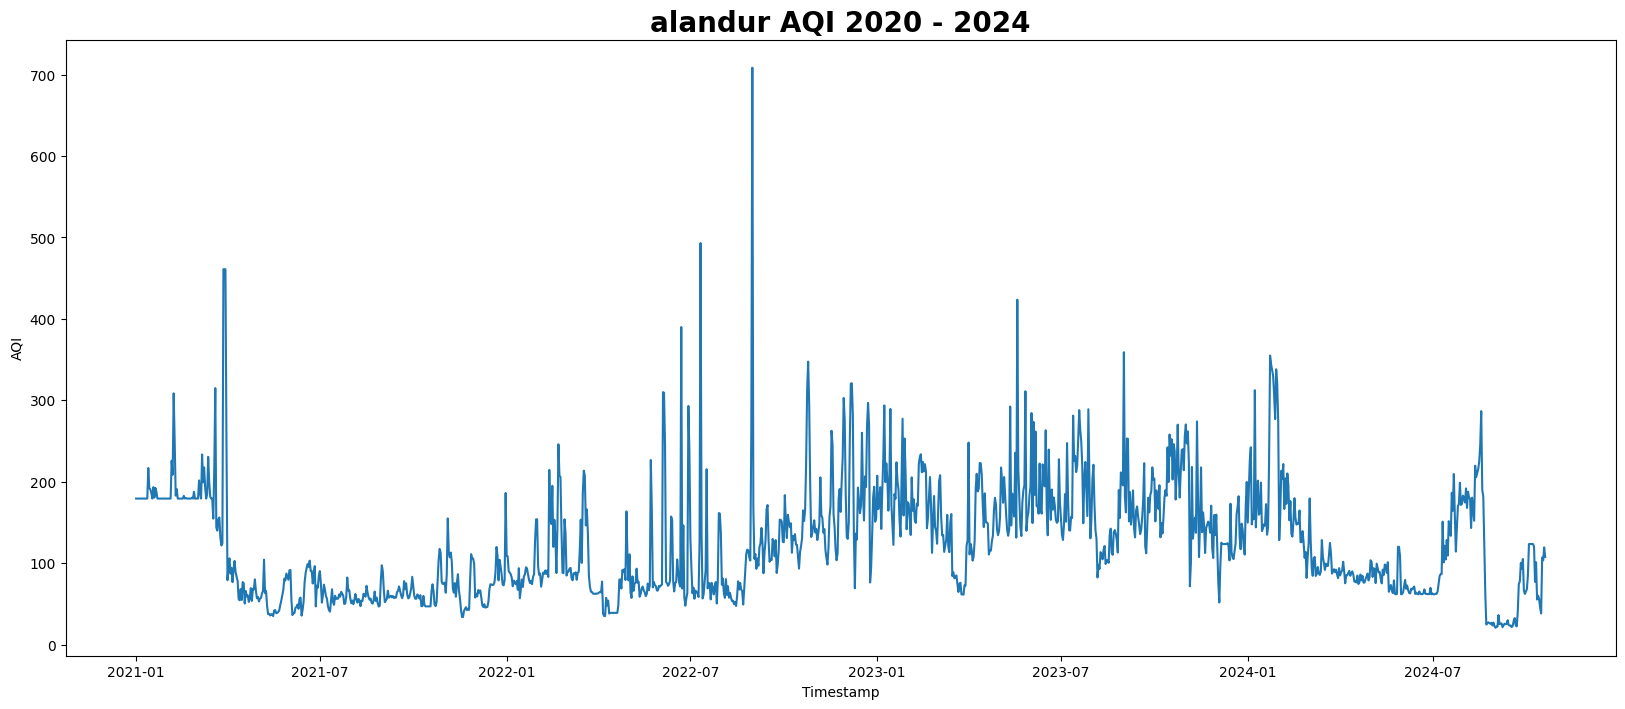

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20,8))
sns.lineplot(data = df['AQI'], errorbar=None)
plt.title('alandur AQI 2020 - 2024', fontdict= {"fontsize": 20, "fontweight": "bold"})

## ACF and PACF

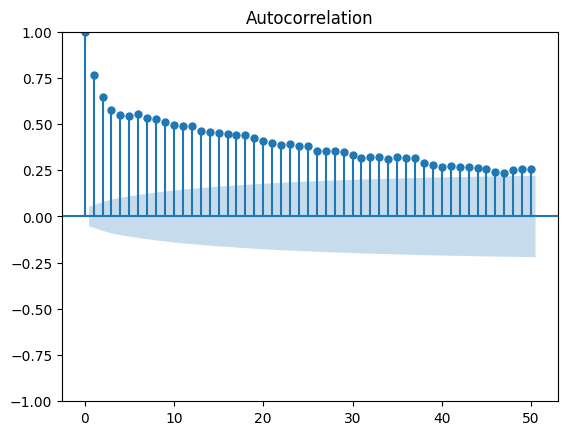

In [22]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
acf_plot = plot_acf(df['AQI'], lags= 50)

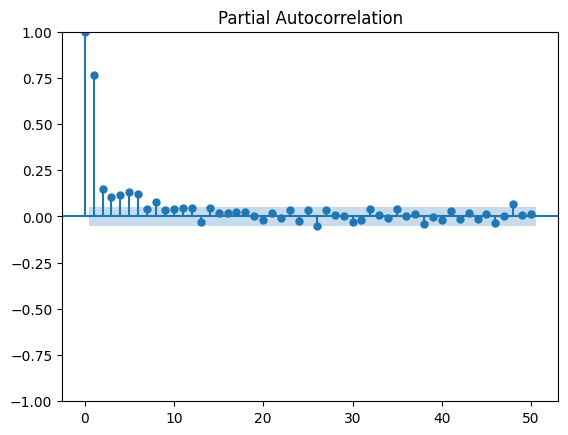

In [23]:
pacf_plot = plot_pacf(df['AQI'], lags= 50)

In [24]:
import statsmodels.api as sm

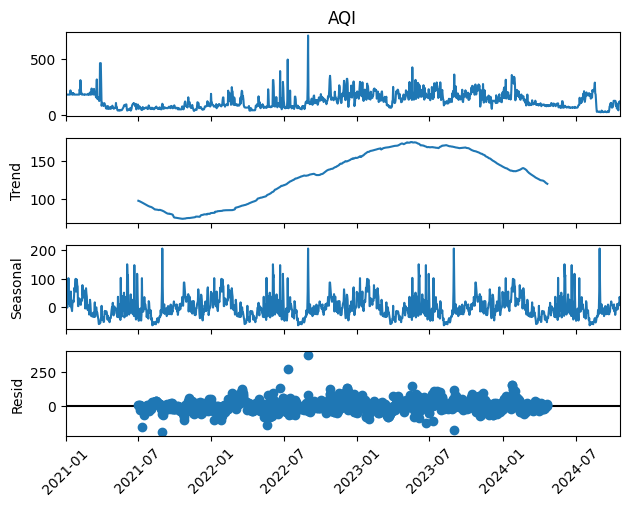

In [25]:
from statsmodels.tsa.seasonal import seasonal_decompose

df.index = pd.to_datetime(df.index)  # Convert index to datetime
result = seasonal_decompose(df['AQI'], model='additive', period=365)  # Adjust period as needed

result.plot()
plt.xticks(rotation=45)  # Ensure readable dates
plt.show()

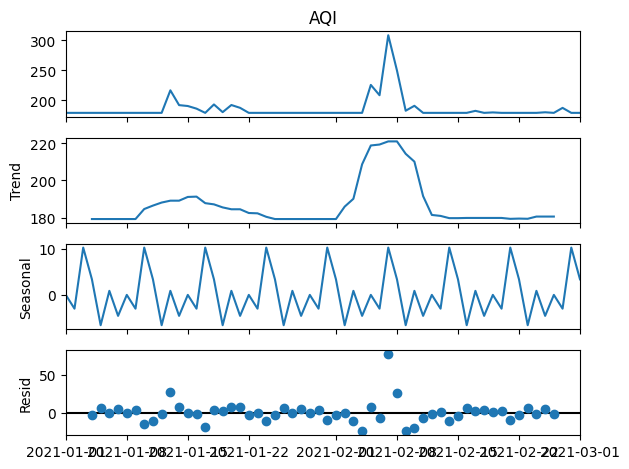

In [26]:
decomp = sm.tsa.seasonal_decompose(df['AQI'][:60])
_ = decomp.plot()

# Functions

In [27]:
def rolling_model(df, order, seasonal_order, train_end, test_end, results):

    train_data = df[ : train_end]['AQI']
    test_data = df[train_end + timedelta(days=1) : test_end]['AQI']

    train_end_copy = train_end
    
    p, d, q = order
    P, D, Q, s = seasonal_order

    rolling_predictions = test_data.copy()

    for train_end in test_data.index:
        train_data = df[ : train_end - timedelta(days=1)]['AQI']
        
        model = SARIMAX(train_data, order=order, seasonal_order=seasonal_order)
        model_fit = model.fit()

        prediction = model_fit.forecast(typ='levels')
        rolling_predictions[train_end] = prediction
    
    residuals = test_data - rolling_predictions
    
    plt.figure(figsize=(14,7))
    plt.plot(residuals)
    plt.axhline(0, linestyle='--', color='k')
    plt.title(f'Residuals from SARIMAX {order} {seasonal_order}', fontsize=20)
    plt.ylabel('Error', fontsize=16)

    plt.figure(figsize=(14, 7))
    plt.plot(test_data)
    plt.plot(rolling_predictions, '--')
    plt.legend(('Data', 'Rolling Predictions'), fontsize=16)
    plt.title(f"AQI daily SARIMAX {order} {seasonal_order}")
    
    results = append_to_results(train_end_copy, test_end, p, d, q, P, D, Q, s, test_data[:-1],
                            rolling_predictions.shift(-1)[:-1], True,
                            model_fit, results)
    return results

In [28]:
def without_rolling_model(df, order, seasonal_order, train_end, test_end, results):

    train_data = df[ : train_end]['AQI']
    test_data = df[train_end + timedelta(days=1) : test_end]['AQI']

    train_end_copy = train_end
    
    p, d, q = order
    P, D, Q, s = seasonal_order

    model = SARIMAX(train_data, order=order, seasonal_order = seasonal_order)
    model_fit = model.fit()
    
    predictions = model_fit.forecast(len(test_data))
    predictions = pd.Series(predictions, index=test_data.index)
    residuals = test_data - predictions

    plt.figure(figsize=(14,7))
    plt.plot(residuals)
    plt.axhline(0, linestyle='--', color='k')
    plt.title(f'Residuals from SARIMAX {order} {seasonal_order}', fontsize=20)
    plt.ylabel('Error', fontsize=16)

    plt.figure(figsize=(14, 7))
    plt.plot(test_data)
    plt.plot(predictions, '--')
    plt.legend(('Data', 'Predictions'), fontsize=16)
    plt.title(f"AQI daily SARIMAX {order} {seasonal_order}")
    
    results = append_to_results(train_end_copy, test_end, p, d, q, P, D, Q, s, test_data,
                            predictions, False,
                            model_fit, results)
    return results

(1, 0, 1) (1, 0, 1, 7)


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
/tmp/ipykernel_65997/2161751734.py:20: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  rolling_predictions[train_end] = prediction
/usr/local/python/3.12.1/lib/python3.12/site-packages/s

(1, 0, 1) (1, 0, 1, 30)


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
/tmp/ipykernel_65997/2161751734.py:20: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  rolling_predictions[train_end] = prediction
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/s

,train_end,test_end,p,d,q,P,D,Q,s,MSE,MAE,MAPE,Rolling?,AIC,BIC
0,2023-11-20,2023-12-02,1,0,1,1,0,1,7,263,13,0.095910,True,11261,11285
0,2023-11-20,2023-12-02,1,0,1,1,0,1,30,150,10,0.071328,True,11308,11333


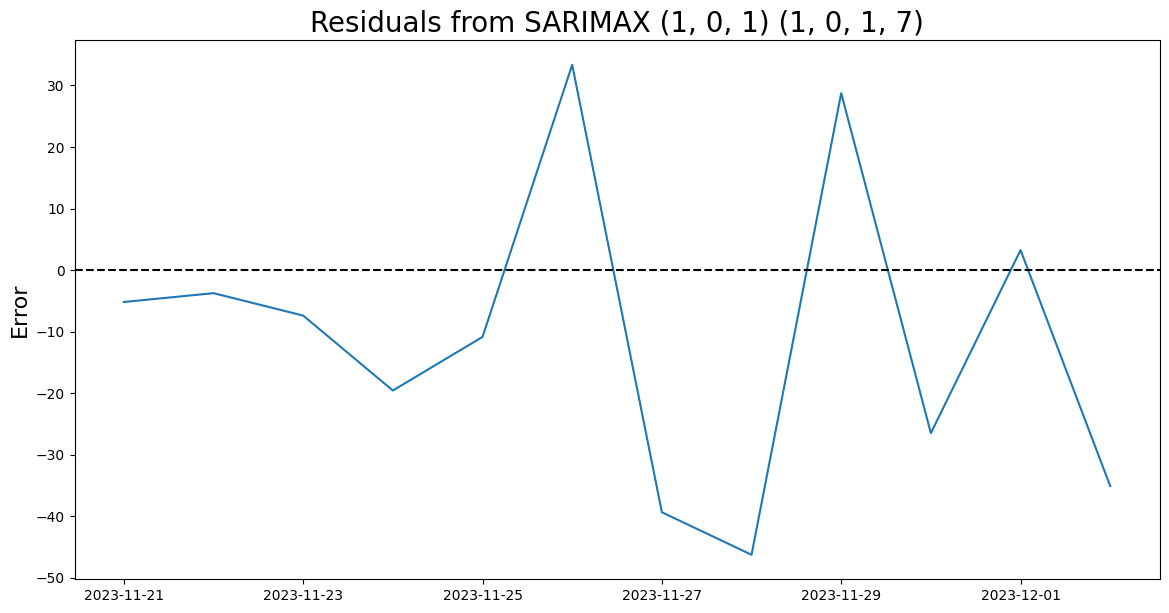

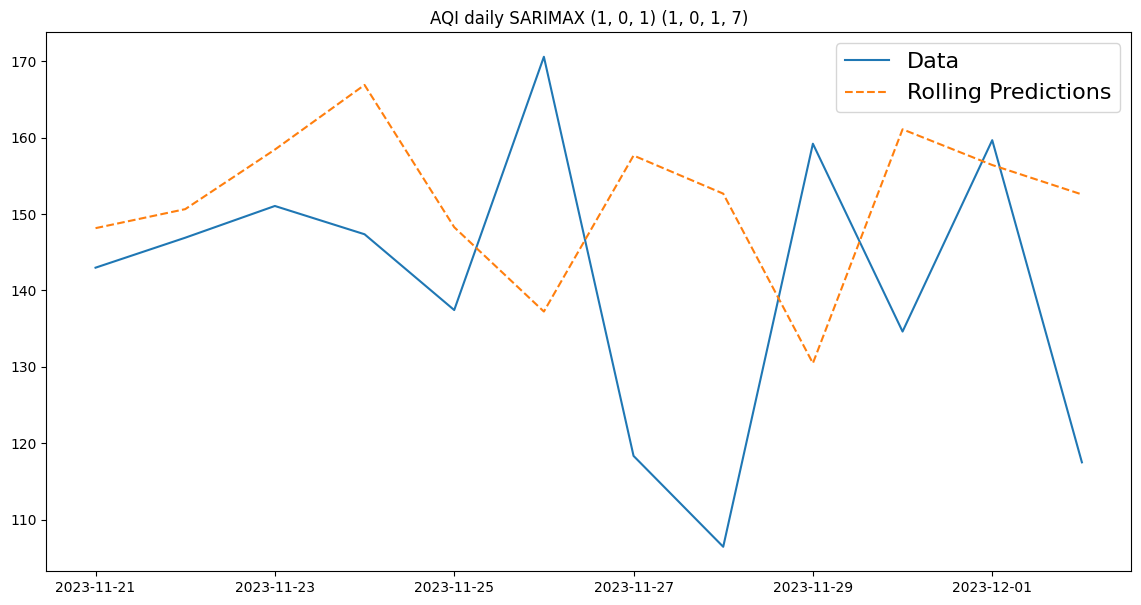

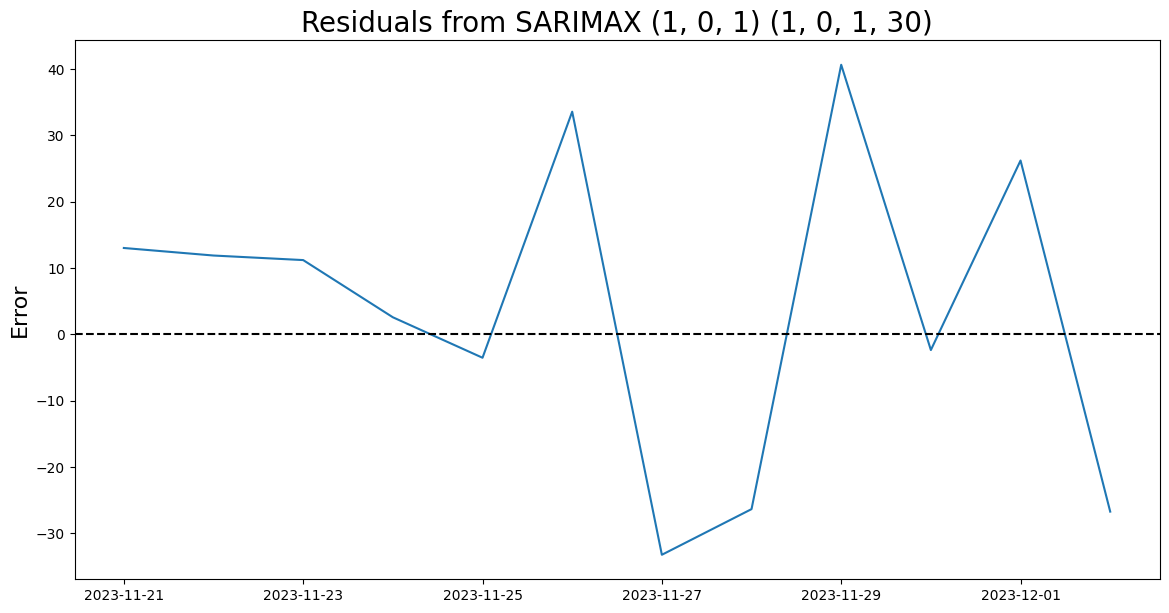

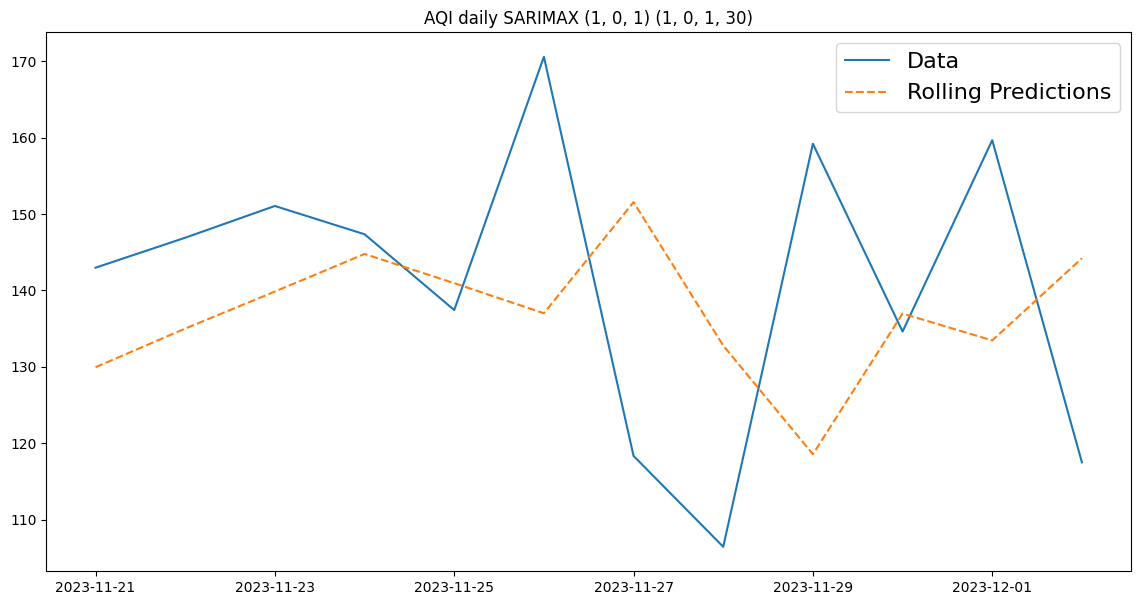

In [29]:
combinations = [[(1, 0, 1), (1, 0, 1, 7)], [(1, 0, 1), (1, 0, 1, 30)]]
for order, seasonal_order in combinations:
    print(order, seasonal_order)
    results = rolling_model(df, order, seasonal_order, datetime(2023, 11, 20), datetime(2023, 12, 2), results)
results

In [30]:
results 

,train_end,test_end,p,d,q,P,D,Q,s,MSE,MAE,MAPE,Rolling?,AIC,BIC
0,2023-11-20,2023-12-02,1,0,1,1,0,1,7,263,13,0.095910,True,11261,11285
0,2023-11-20,2023-12-02,1,0,1,1,0,1,30,150,10,0.071328,True,11308,11333


(3, 0, 1) (3, 0, 1, 7)


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


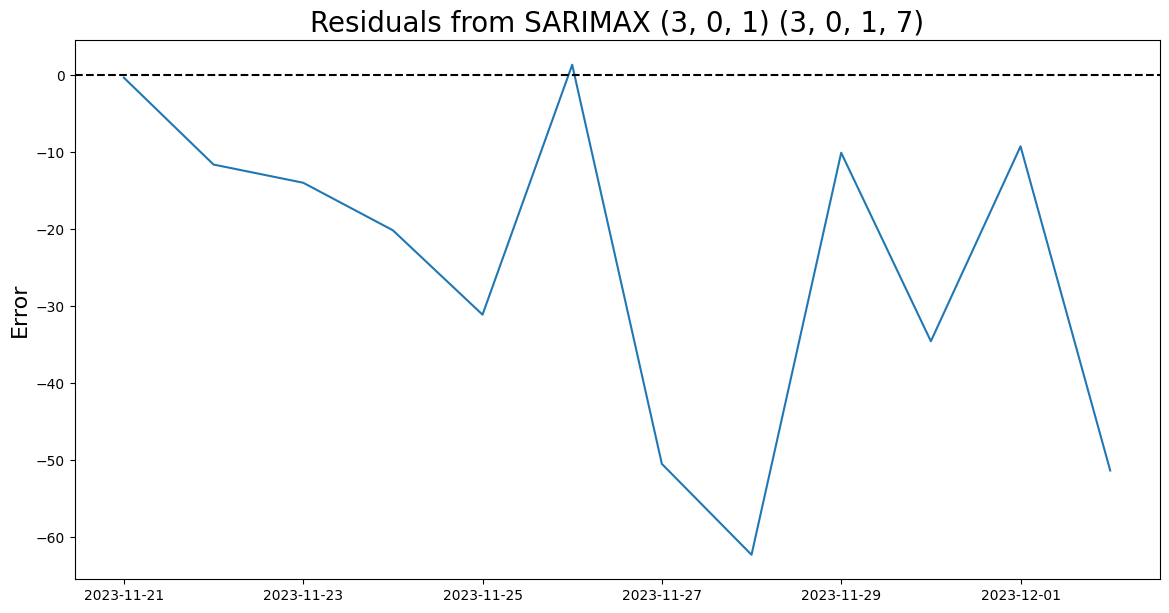

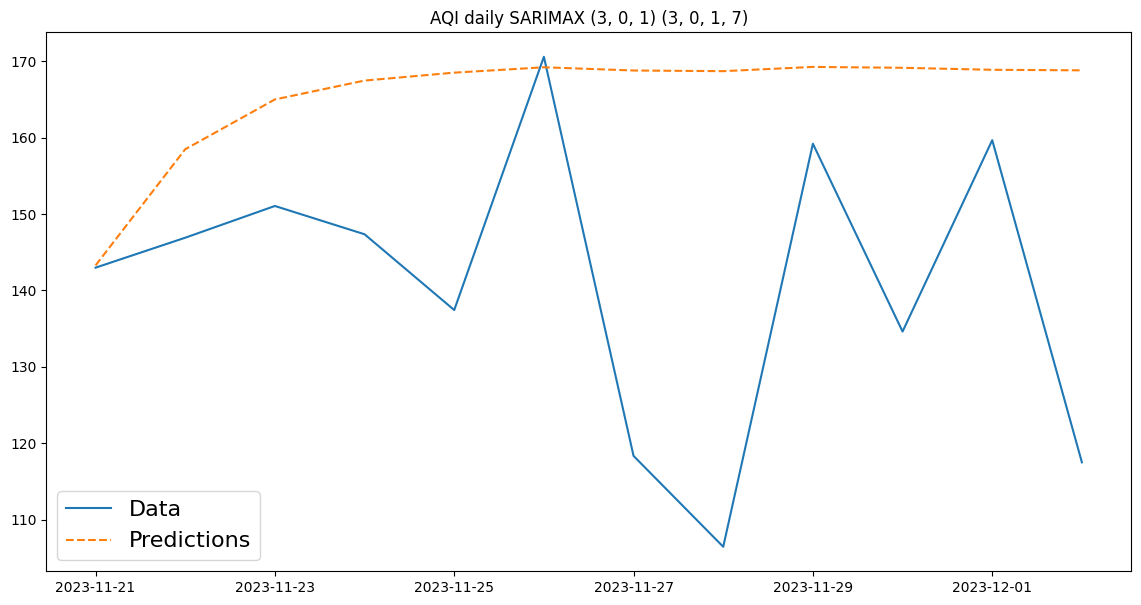

In [31]:
combinations = [[(3, 0, 1), (3, 0, 1, 7)]]
for order, seasonal_order in combinations:
    print(order, seasonal_order)
    results = without_rolling_model(df, order, seasonal_order, datetime(2023, 11, 20), datetime(2023, 12, 2), results)

In [32]:
results

,train_end,test_end,p,d,q,P,D,Q,s,MSE,MAE,MAPE,Rolling?,AIC,BIC
0,2023-11-20,2023-12-02,1,0,1,1,0,1,7,263,13,0.095910,True,11261,11285
0,2023-11-20,2023-12-02,1,0,1,1,0,1,30,150,10,0.071328,True,11308,11333
0,2023-11-20,2023-12-02,3,0,1,3,0,1,7,1012,25,0.197513,False,11083,11127


In [33]:
results

,train_end,test_end,p,d,q,P,D,Q,s,MSE,MAE,MAPE,Rolling?,AIC,BIC
0,2023-11-20,2023-12-02,1,0,1,1,0,1,7,263,13,0.095910,True,11261,11285
0,2023-11-20,2023-12-02,1,0,1,1,0,1,30,150,10,0.071328,True,11308,11333
0,2023-11-20,2023-12-02,3,0,1,3,0,1,7,1012,25,0.197513,False,11083,11127


(1, 0, 0) (1, 1, 0, 7)


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


(1, 0, 1) (1, 1, 0, 7)


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


(1, 0, 1) (1, 1, 1, 7)


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


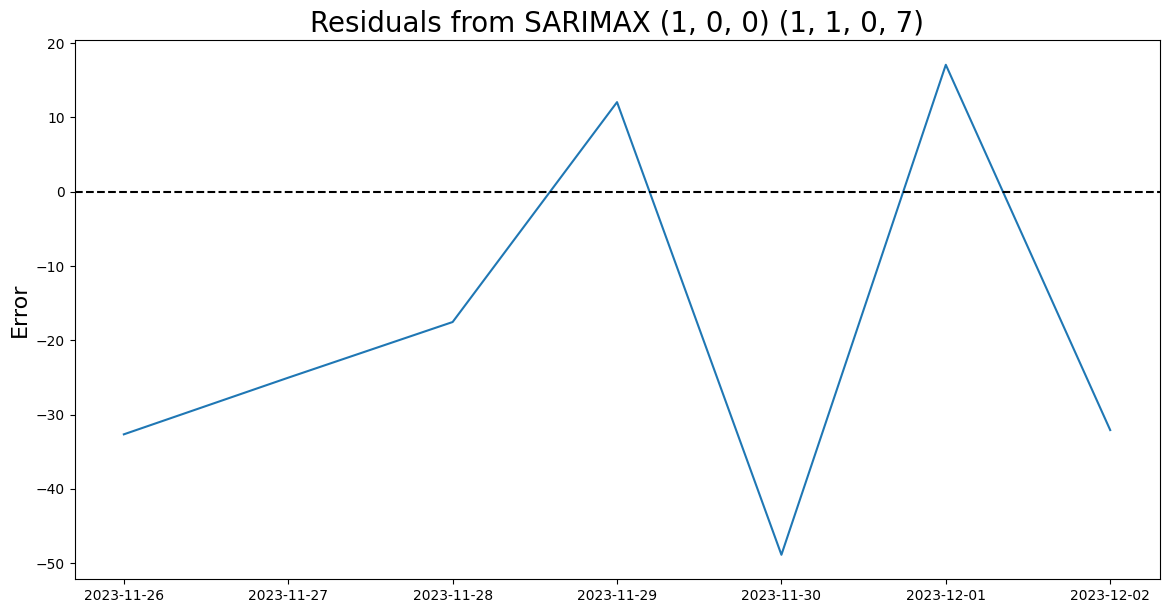

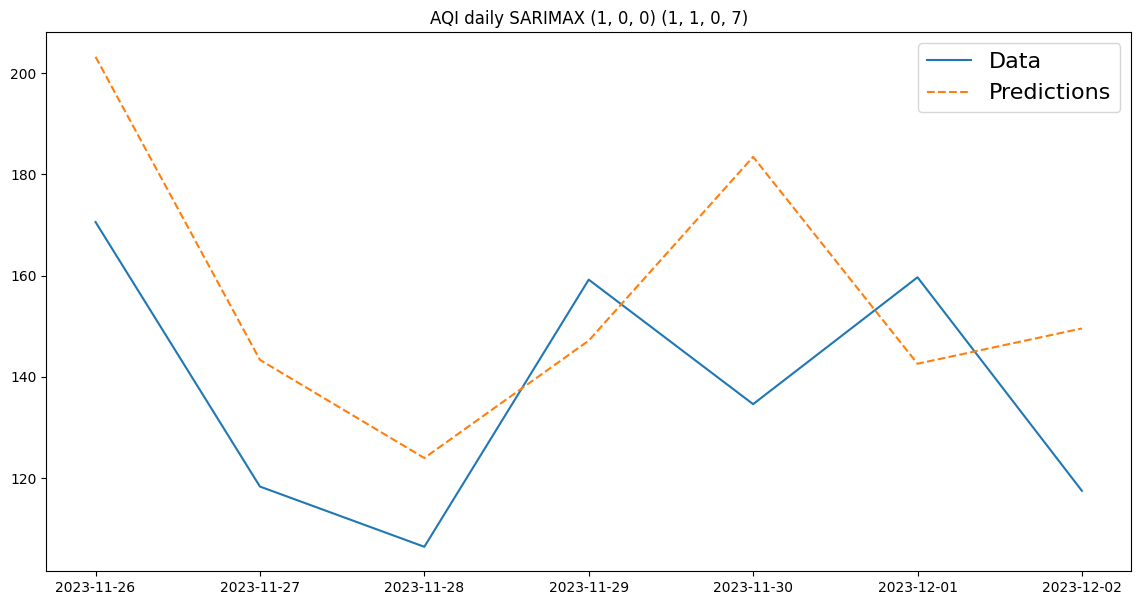

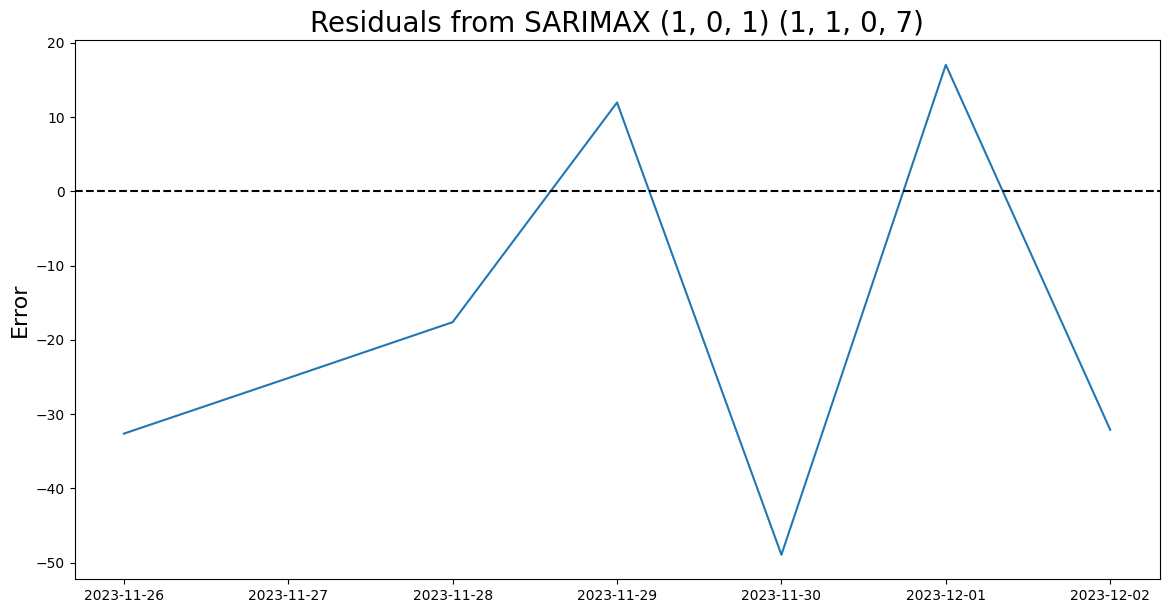

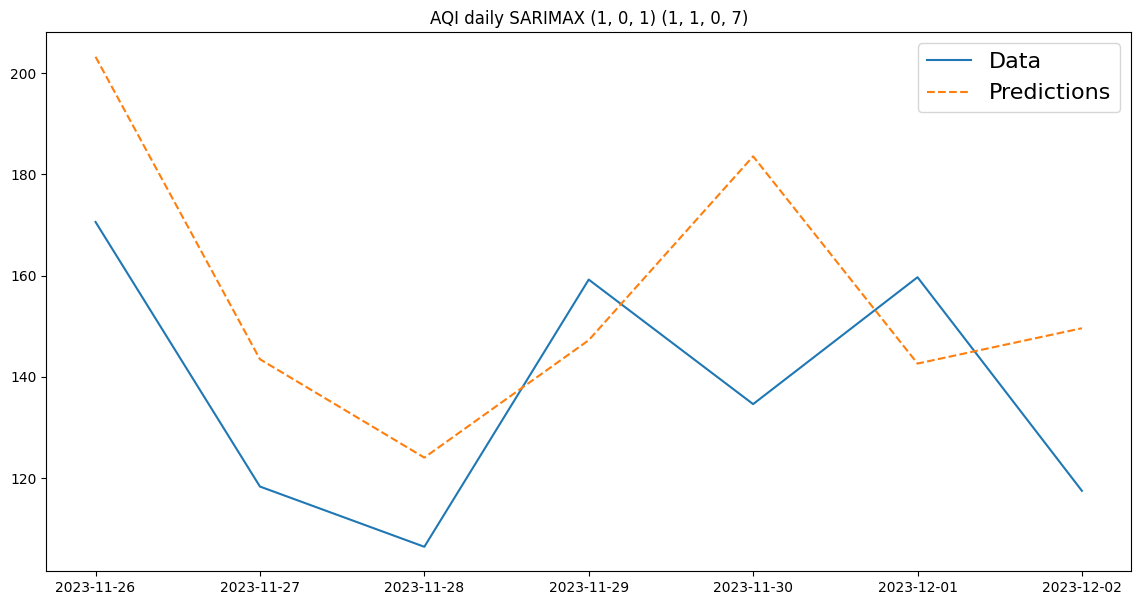

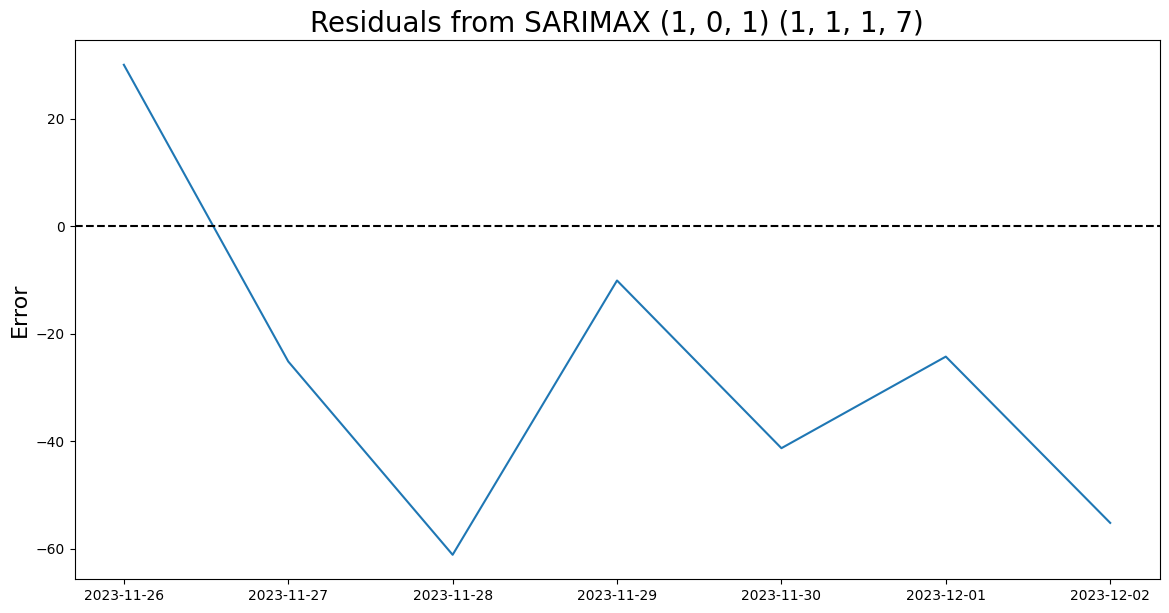

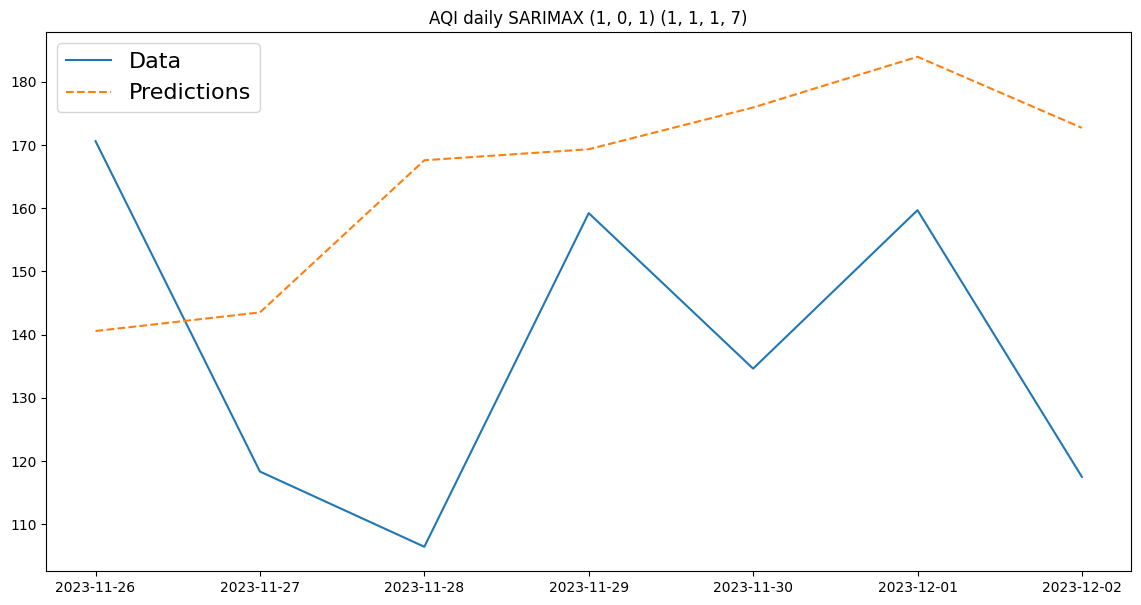

In [34]:
combinations = [[(1, 0, 0), (1, 1, 0, 7)], [(1, 0, 1), (1, 1, 0, 7)], [(1, 0, 1), (1, 1, 1, 7)]]

for order, seasonal_order in combinations:
    print(order, seasonal_order)
    results = without_rolling_model(df, order, seasonal_order, datetime(2023, 11, 25), datetime(2023, 12, 2), results)

In [35]:
results

,train_end,test_end,p,d,q,P,D,Q,s,MSE,MAE,MAPE,Rolling?,AIC,BIC
0,2023-11-20,2023-12-02,1,0,1,1,0,1,7,263,13,0.095910,True,11261,11285
0,2023-11-20,2023-12-02,1,0,1,1,0,1,30,150,10,0.071328,True,11308,11333
0,2023-11-20,2023-12-02,3,0,1,3,0,1,7,1012,25,0.197513,False,11083,11127
0,2023-11-25,2023-12-02,1,0,0,1,1,0,7,836,26,0.198041,False,11424,11439
0,2023-11-25,2023-12-02,1,0,1,1,1,0,7,838,26,0.198309,False,11425,11445
0,2023-11-25,2023-12-02,1,0,1,1,1,1,7,1532,35,0.279360,False,11126,11150


## Changing train data - forecast 5 days

(1, 0, 1) (1, 0, 1, 7)


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


(3, 0, 1) (3, 0, 1, 7)


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(1, 0, 1) (1, 0, 1, 30)


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


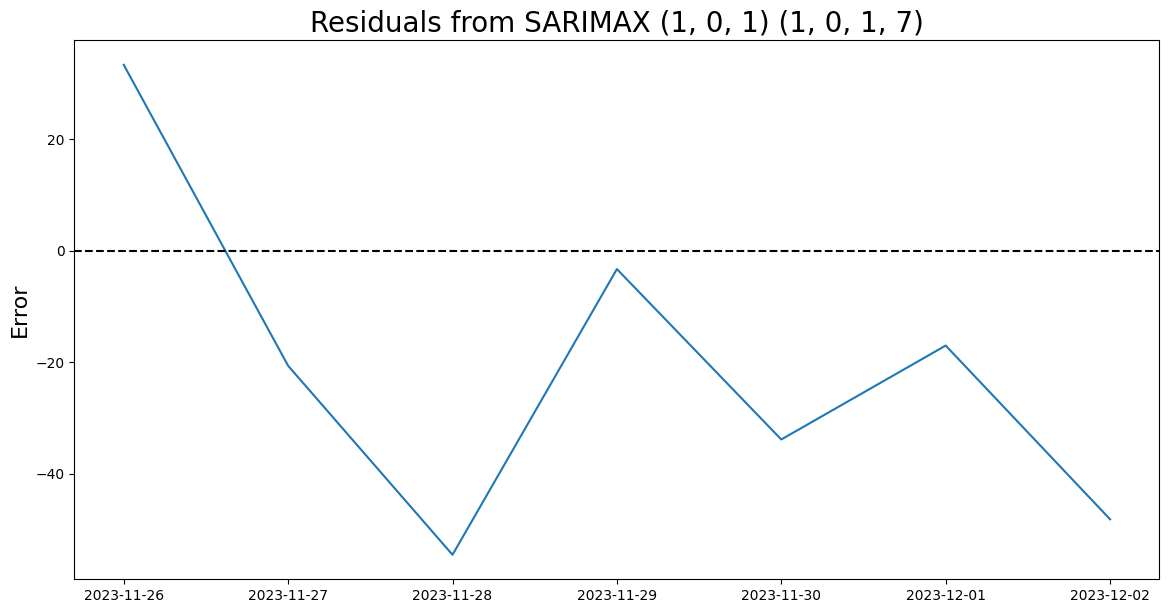

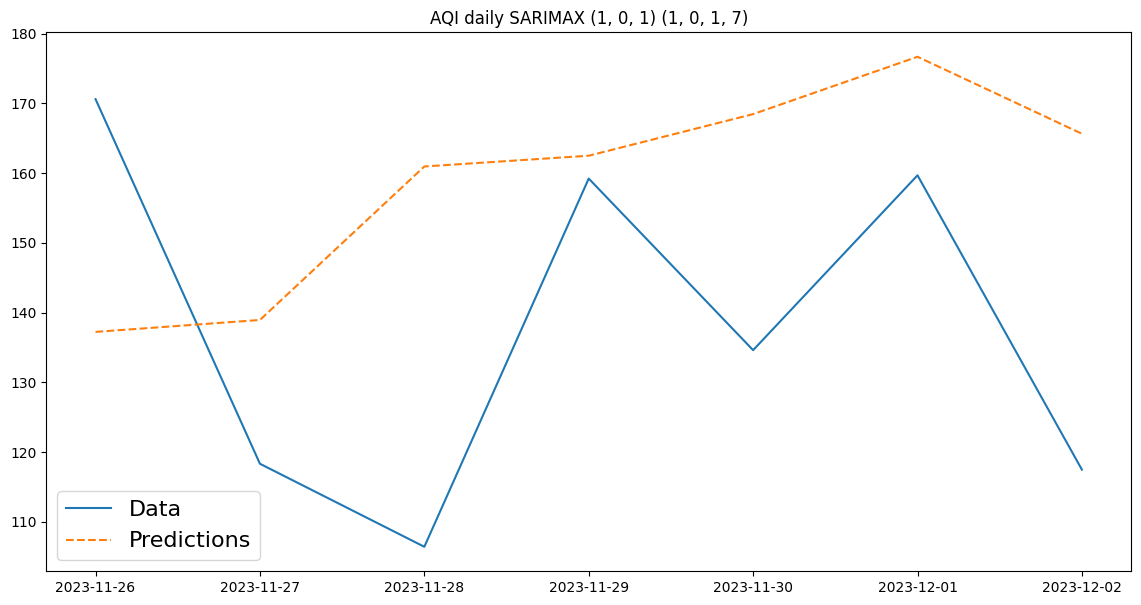

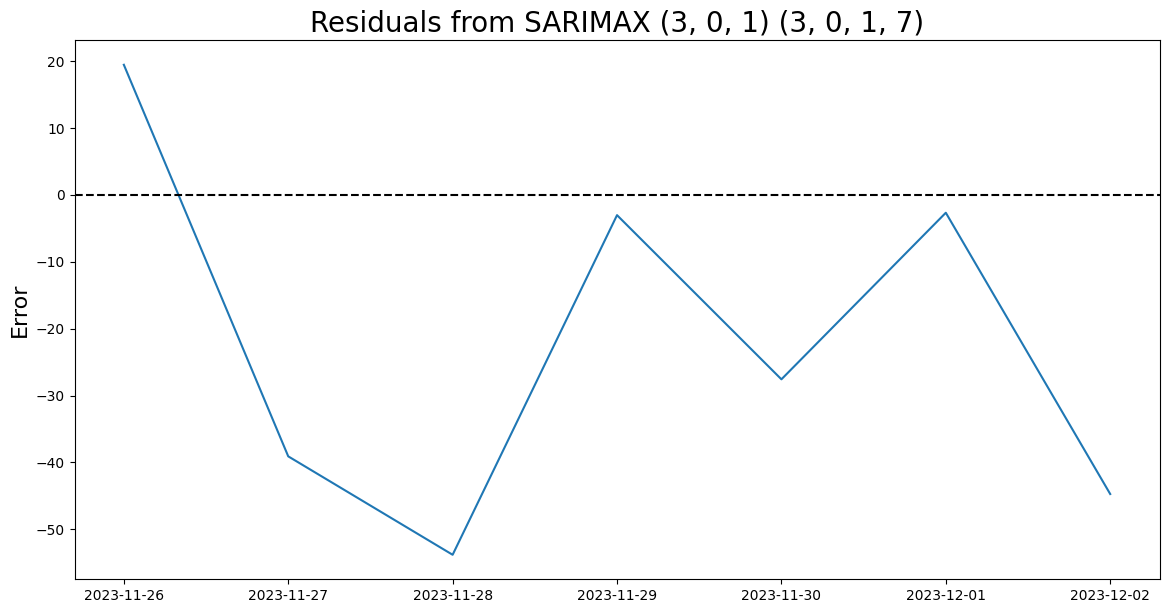

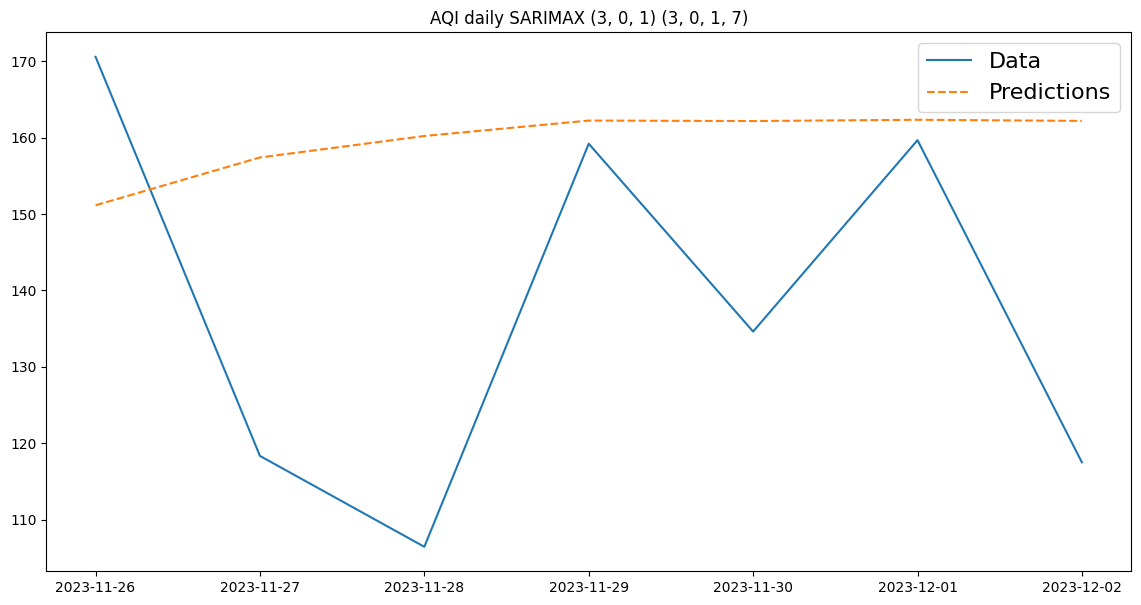

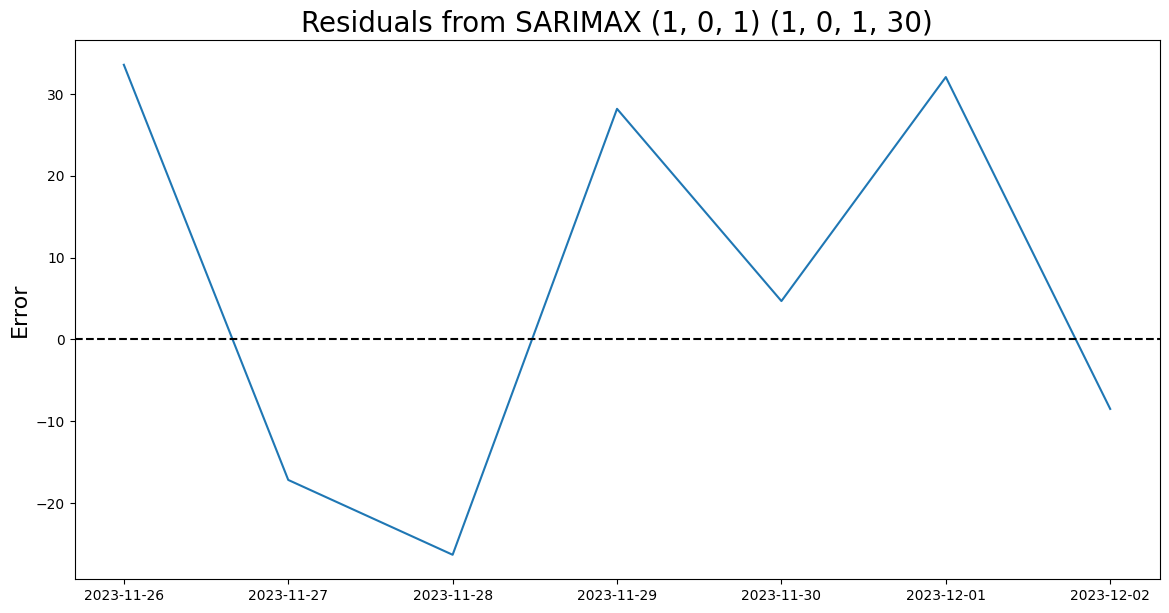

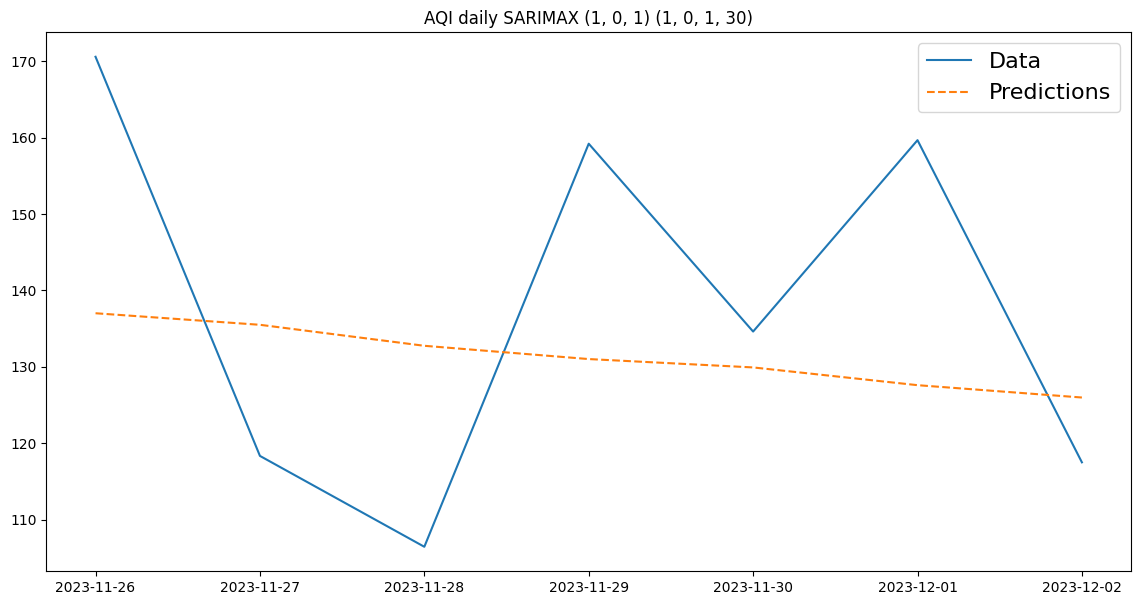

In [36]:
combinations = [[(1, 0, 1), (1, 0, 1, 7)], [(3, 0, 1), (3, 0, 1, 7)], [(1, 0, 1), (1, 0, 1, 30)]]

for order, seasonal_order in combinations:
    print(order, seasonal_order)
    results = without_rolling_model(df, order, seasonal_order, datetime(2023, 11, 25), datetime(2023, 12, 2), results)

In [37]:
results 

,train_end,test_end,p,d,q,P,D,Q,s,MSE,MAE,MAPE,Rolling?,AIC,BIC
0,2023-11-20,2023-12-02,1,0,1,1,0,1,7,263,13,0.095910,True,11261,11285
0,2023-11-20,2023-12-02,1,0,1,1,0,1,30,150,10,0.071328,True,11308,11333
0,2023-11-20,2023-12-02,3,0,1,3,0,1,7,1012,25,0.197513,False,11083,11127
0,2023-11-25,2023-12-02,1,0,0,1,1,0,7,836,26,0.198041,False,11424,11439
0,2023-11-25,2023-12-02,1,0,1,1,1,0,7,838,26,0.198309,False,11425,11445
0,2023-11-25,2023-12-02,1,0,1,1,1,1,7,1532,35,0.279360,False,11126,11150
0,2023-11-25,2023-12-02,1,0,1,1,0,1,7,1182,30,0.238585,False,11200,11225
0,2023-11-25,2023-12-02,3,0,1,3,0,1,7,1082,27,0.224394,False,11131,11175
0,2023-11-25,2023-12-02,1,0,1,1,0,1,30,576,22,0.153490,False,11248,11273


(1, 0, 1) (1, 0, 1, 120)


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'


(1, 0, 1) (1, 1, 1, 120)


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(1, 0, 1) (1, 1, 1, 30)


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


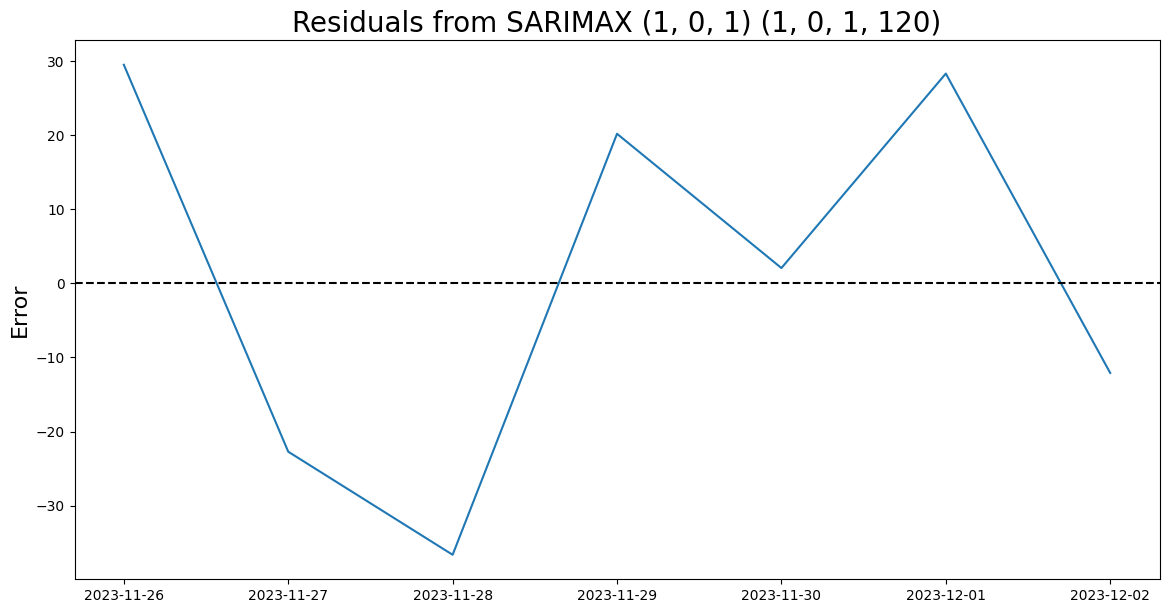

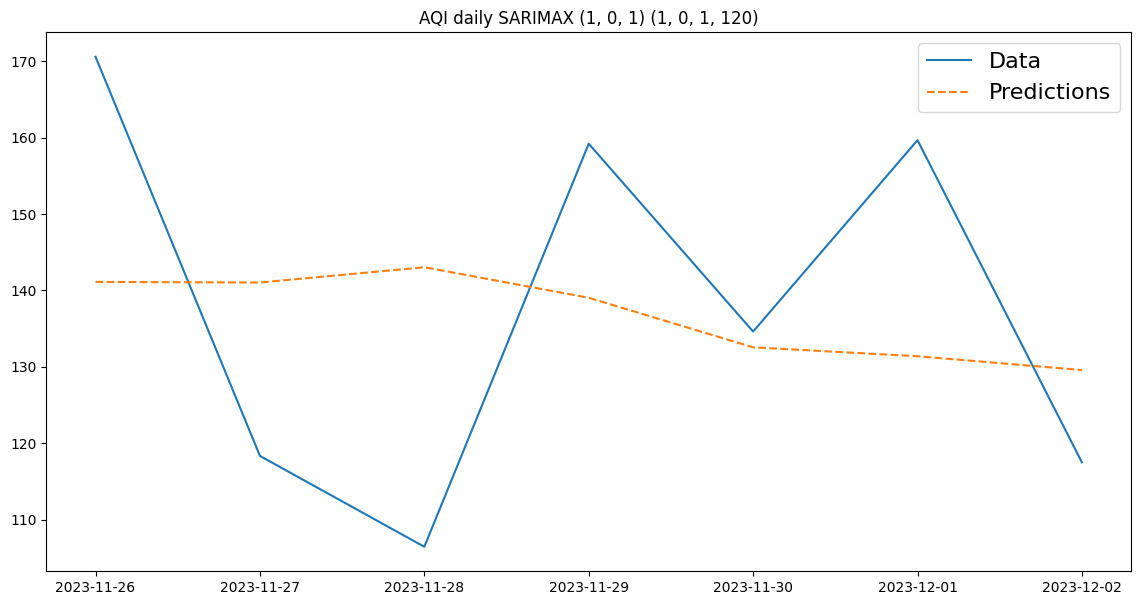

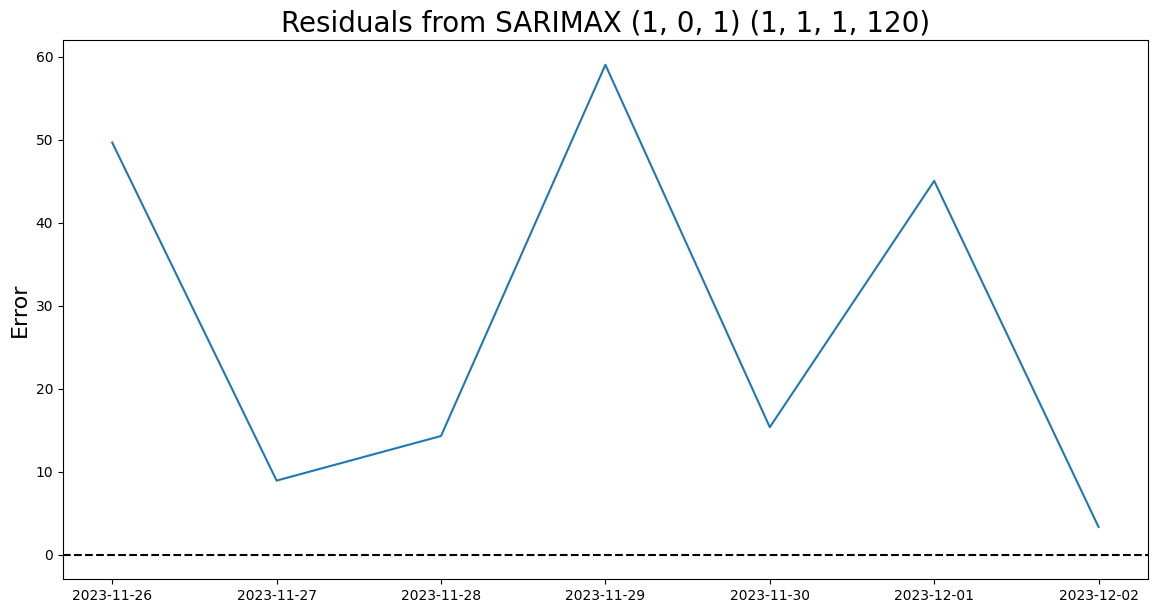

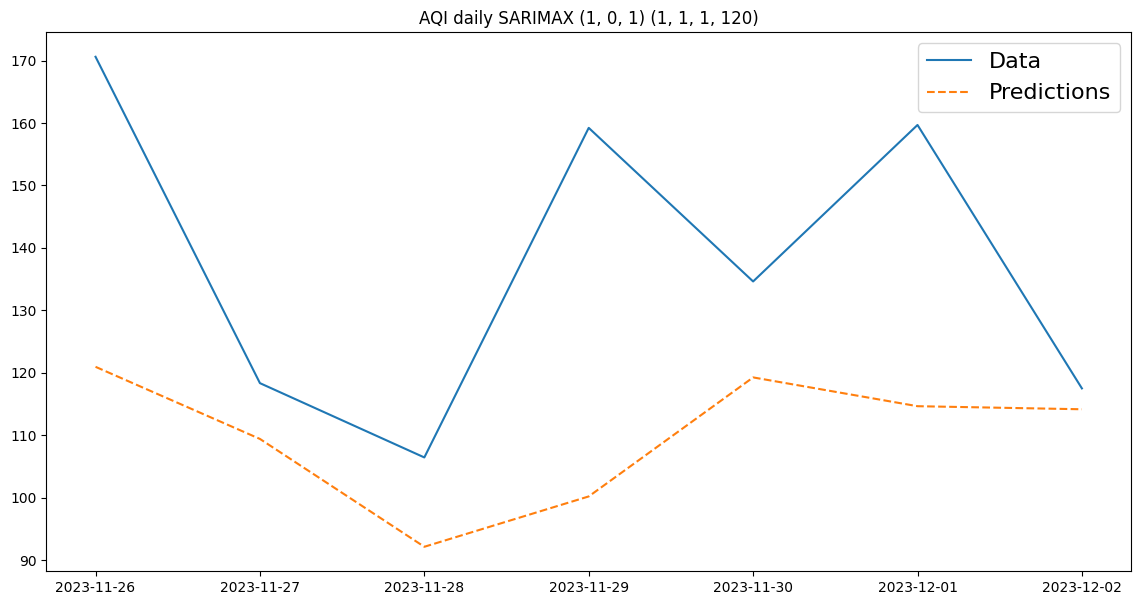

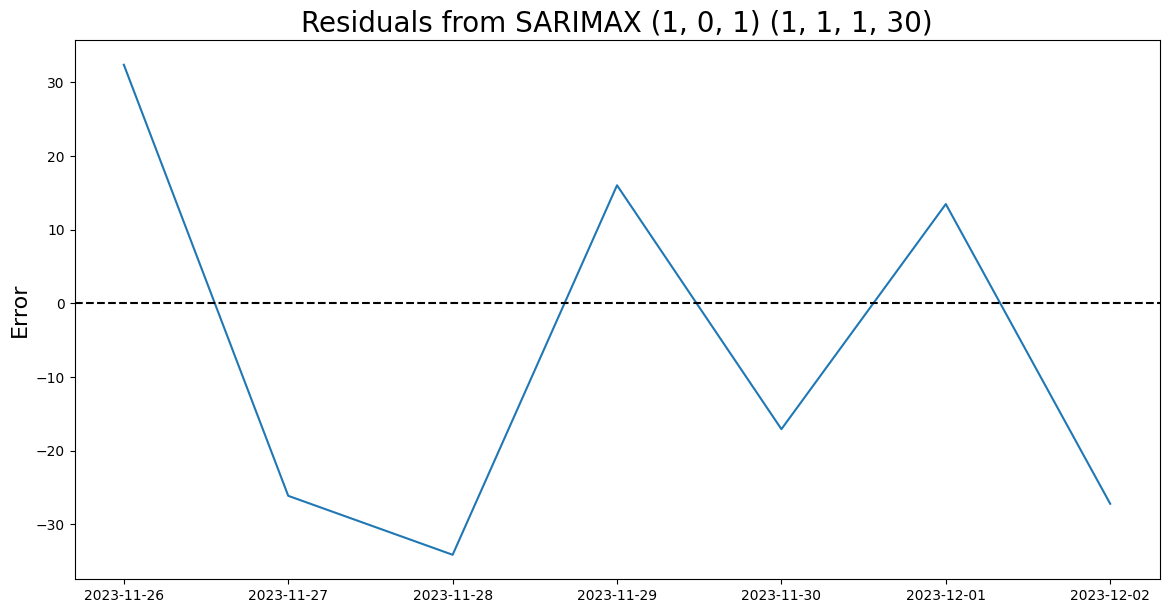

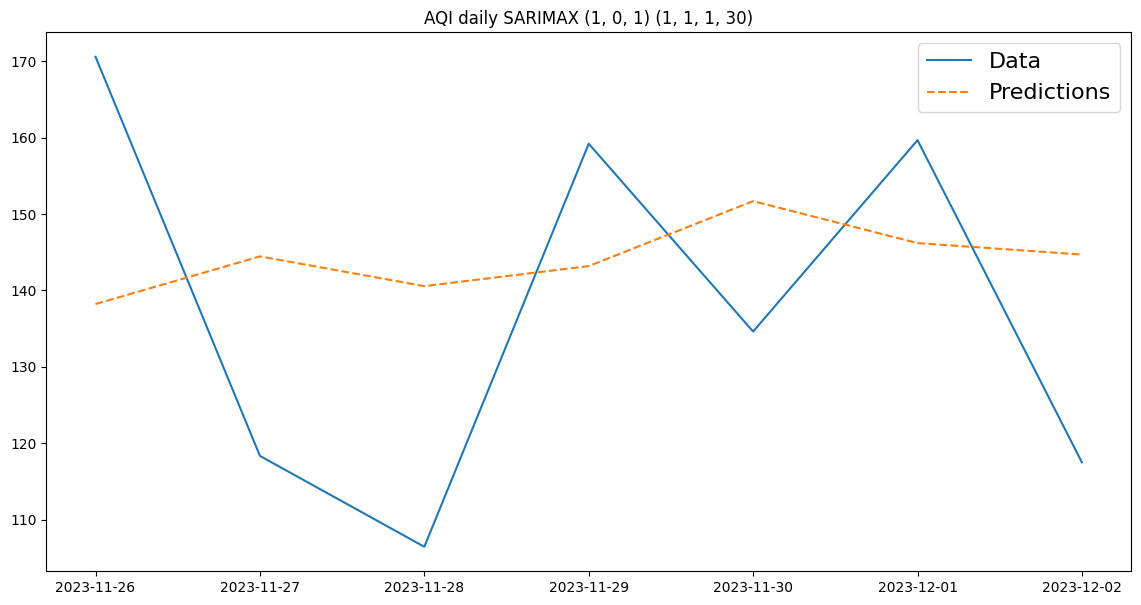

In [38]:
combinations = [[(1, 0, 1), (1, 0, 1, 120)], [(1, 0, 1), (1, 1, 1, 120)], [(1, 0, 1), (1, 1, 1, 30)]]

for order, seasonal_order in combinations:
    print(order, seasonal_order)
    results = without_rolling_model(df, order, seasonal_order, datetime(2023, 11, 25), datetime(2023, 12, 2), results)

In [39]:
results

,train_end,test_end,p,d,q,P,D,Q,s,MSE,MAE,MAPE,Rolling?,AIC,BIC
0,2023-11-20,2023-12-02,1,0,1,1,0,1,7,263,13,0.095910,True,11261,11285
0,2023-11-20,2023-12-02,1,0,1,1,0,1,30,150,10,0.071328,True,11308,11333
0,2023-11-20,2023-12-02,3,0,1,3,0,1,7,1012,25,0.197513,False,11083,11127
0,2023-11-25,2023-12-02,1,0,0,1,1,0,7,836,26,0.198041,False,11424,11439
0,2023-11-25,2023-12-02,1,0,1,1,1,0,7,838,26,0.198309,False,11425,11445
0,2023-11-25,2023-12-02,1,0,1,1,1,1,7,1532,35,0.279360,False,11126,11150
0,2023-11-25,2023-12-02,1,0,1,1,0,1,7,1182,30,0.238585,False,11200,11225
0,2023-11-25,2023-12-02,3,0,1,3,0,1,7,1082,27,0.224394,False,11131,11175
0,2023-11-25,2023-12-02,1,0,1,1,0,1,30,576,22,0.153490,False,11248,11273
0,2023-11-25,2023-12-02,1,0,1,1,0,1,120,583,22,0.161534,False,11246,11271


In [40]:
results.to_csv("models_results.csv")

In [41]:
# best_model = # 2023-11-25	2023-12-02	1	0	1	1	0	1	7	2398	36	0.137155	False

In [44]:
from pmdarima import auto_arima
stepwise_fit = auto_arima(
    alandur_daily['AQI_calculated'],
    suppress_warnings=True,
    d=0,  # non-seasonal difference order
    start_p=0,  # initial guess for p
    start_q=0,  # initial guess for q
    max_p=2,  # max value of p to test
    max_q=2,  # max value of q to test
    seasonal=True,  # is the time series seasonal? YES
    m=24,  # the seasonal period
    #D=1, # seasonal difference order
    start_P=0,  # initial guess for P
    start_Q=0,  # initial guess for Q
    max_P=2,  # max value of P to test
    max_Q=2,  # max value of Q to test
    information_criterion='aic',  # used to select best model
    trace=True,  # print results whilst training
    error_action='ignore',  # ignore orders that don't work
    stepwise=True  # apply intelligent order search
)
stepwise_fit.summary()

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

# Training rolling ARIMA 1,0,1

In [ ]:
train_end = datetime(2023, 11, 20)
test_end = datetime(2023, 12, 2)

train_data = df[:train_end]['AQI']
test_data = df[train_end + timedelta(days=1):test_end]['AQI']

my_order = (1, 0, 1)
seasonal_oder = (0, 0, 0, 0)
p, d, q = my_order
P, D, Q, s = seasonal_oder

rolling_predictions = test_data.copy()

for train_end in test_data.index:
    print("train_end-timedelta(days=1)", train_end - timedelta(days=1))
    train_data = df[:train_end - timedelta(days=1)]['AQI']
    model = ARIMA(train_data, order=my_order)
    model_fit = model.fit()
    pred = model_fit.forecast(typ='levels')
    print("pred", pred)
    rolling_predictions[train_end] = pred

train_end-timedelta(days=1) 2023-11-20 00:00:00
pred 2023-11-21    324.210765
Freq: D, dtype: float64
train_end-timedelta(days=1) 2023-11-21 00:00:00


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.frame

pred 2023-11-22    311.615417
Freq: D, dtype: float64
train_end-timedelta(days=1) 2023-11-22 00:00:00
pred 2023-11-23    321.83146
Freq: D, dtype: float64
train_end-timedelta(days=1) 2023-11-23 00:00:00


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.frame

pred 2023-11-24    394.338952
Freq: D, dtype: float64
train_end-timedelta(days=1) 2023-11-24 00:00:00
pred 2023-11-25    436.975335
Freq: D, dtype: float64
train_end-timedelta(days=1) 2023-11-25 00:00:00


...

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.frame

pred 2023-11-30    296.746976
Freq: D, dtype: float64
train_end-timedelta(days=1) 2023-11-30 00:00:00


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


pred 2023-12-01    324.020459
Freq: D, dtype: float64
train_end-timedelta(days=1) 2023-12-01 00:00:00
pred 2023-12-02    283.078364
Freq: D, dtype: float64


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [ ]:
residuals = test_data - rolling_predictions.shift(-1)

<Figure size 1400x400 with 0 Axes>

Text(0.5, 1.0, 'Residuals from Rolling ARIMA 1, 0, 1')

Text(0, 0.5, 'Error')

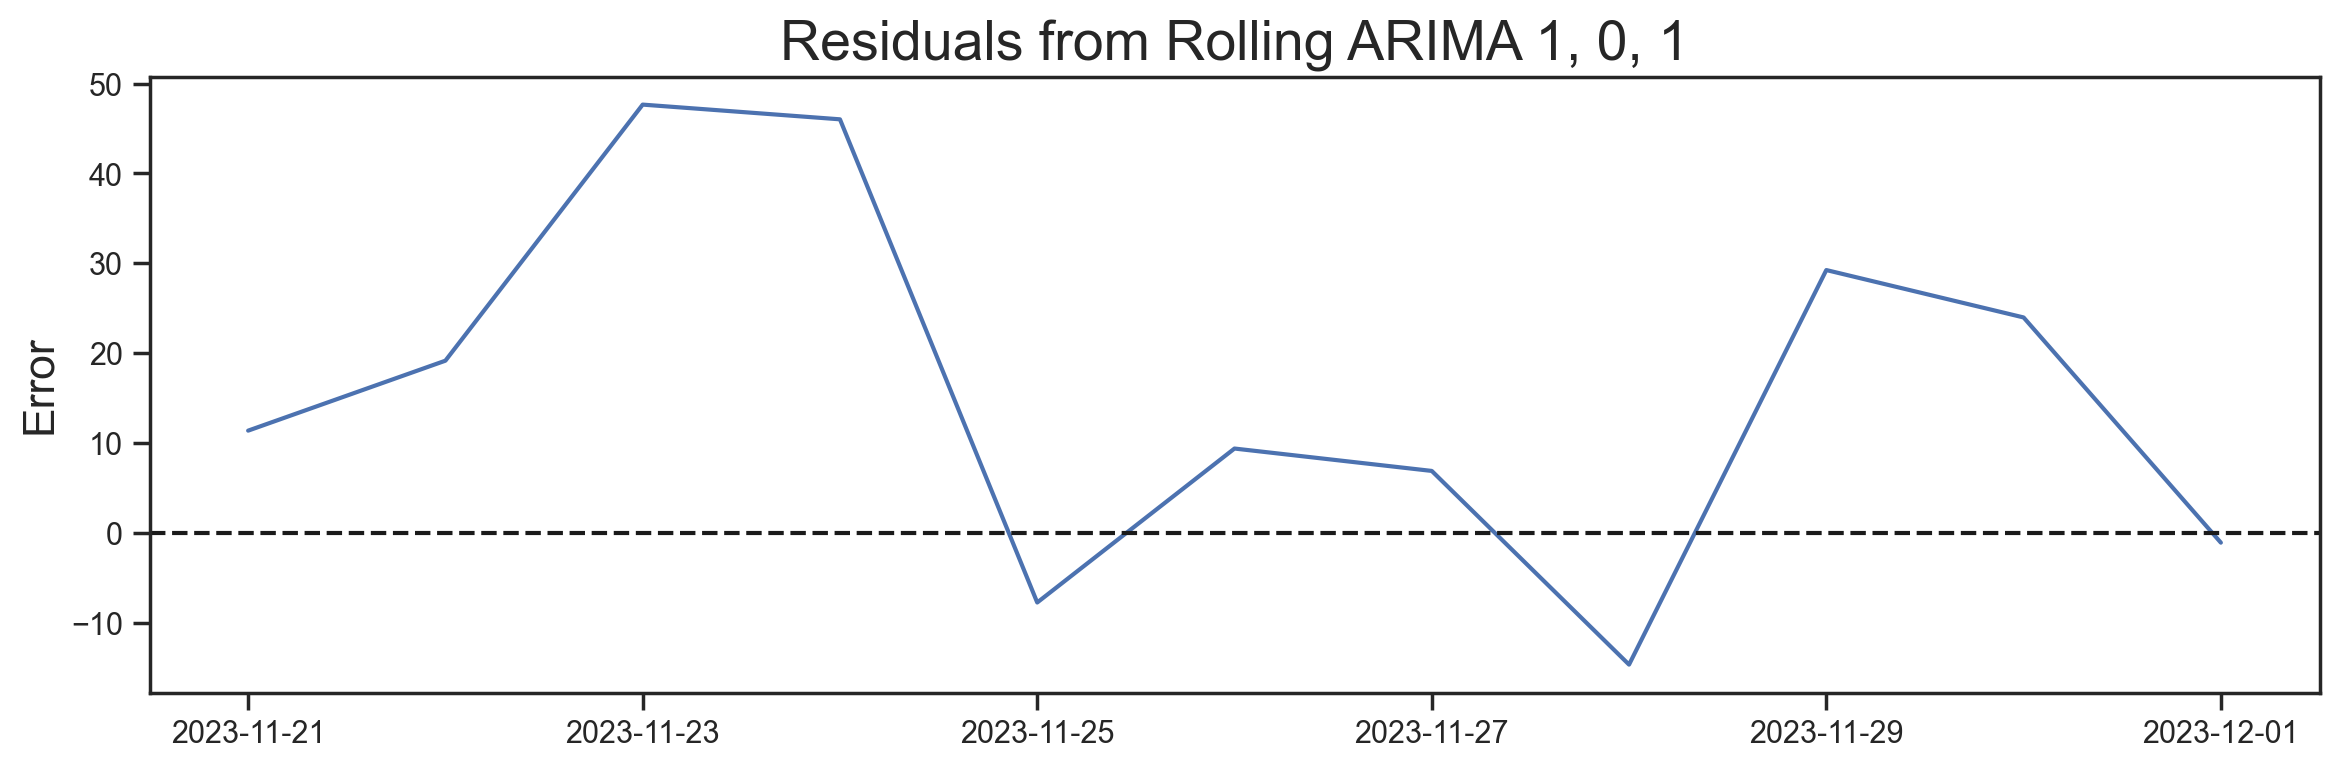

In [ ]:
plt.figure(figsize=(14,4))
plt.plot(residuals)
plt.axhline(0, linestyle='--', color='k')
plt.title('Residuals from Rolling ARIMA {}, {}, {}'.format(p,d,q), fontsize=20)
plt.ylabel('Error', fontsize=16)

In [ ]:
results = append_to_results(p, d, q, P, D, Q, s, test_data[:-1],
                            rolling_predictions.shift(-1)[:-1], True,
                            model_fit, results)
results

,p,d,q,P,D,Q,s,MSE,MAE,MAPE,Rolling?,AIC,BIC
0,1,0,1,0,0,0,0,612.0,20.0,0.05446,True,15327.0,15348.0


In [ ]:
# result = {
#     "p": [p],
#     "d": [d],
#     "q": [q],
#     "P": [P],
#     "D": [D],
#     "Q": [Q],
#     "s": [s],
#     "MSE": [mean_squared_error(test_data[:-1], rolling_predictions.shift(-1)[:-1])],
#     "MAE": [mean_absolute_error(test_data[:-1], rolling_predictions.shift(-1)[:-1])],
#     "MAPE": [mean_absolute_percentage_error(test_data[:-1], rolling_predictions.shift(-1)[:-1])],
#     "Rolling?": [True],
#     "AIC": [model_fit.aic],
#     "BIC": [model_fit.bic]
# }

# result

<Figure size 1400x700 with 0 Axes>

Text(0.5, 1.0, 'predictions ARIMA 1, 0, 1 ')

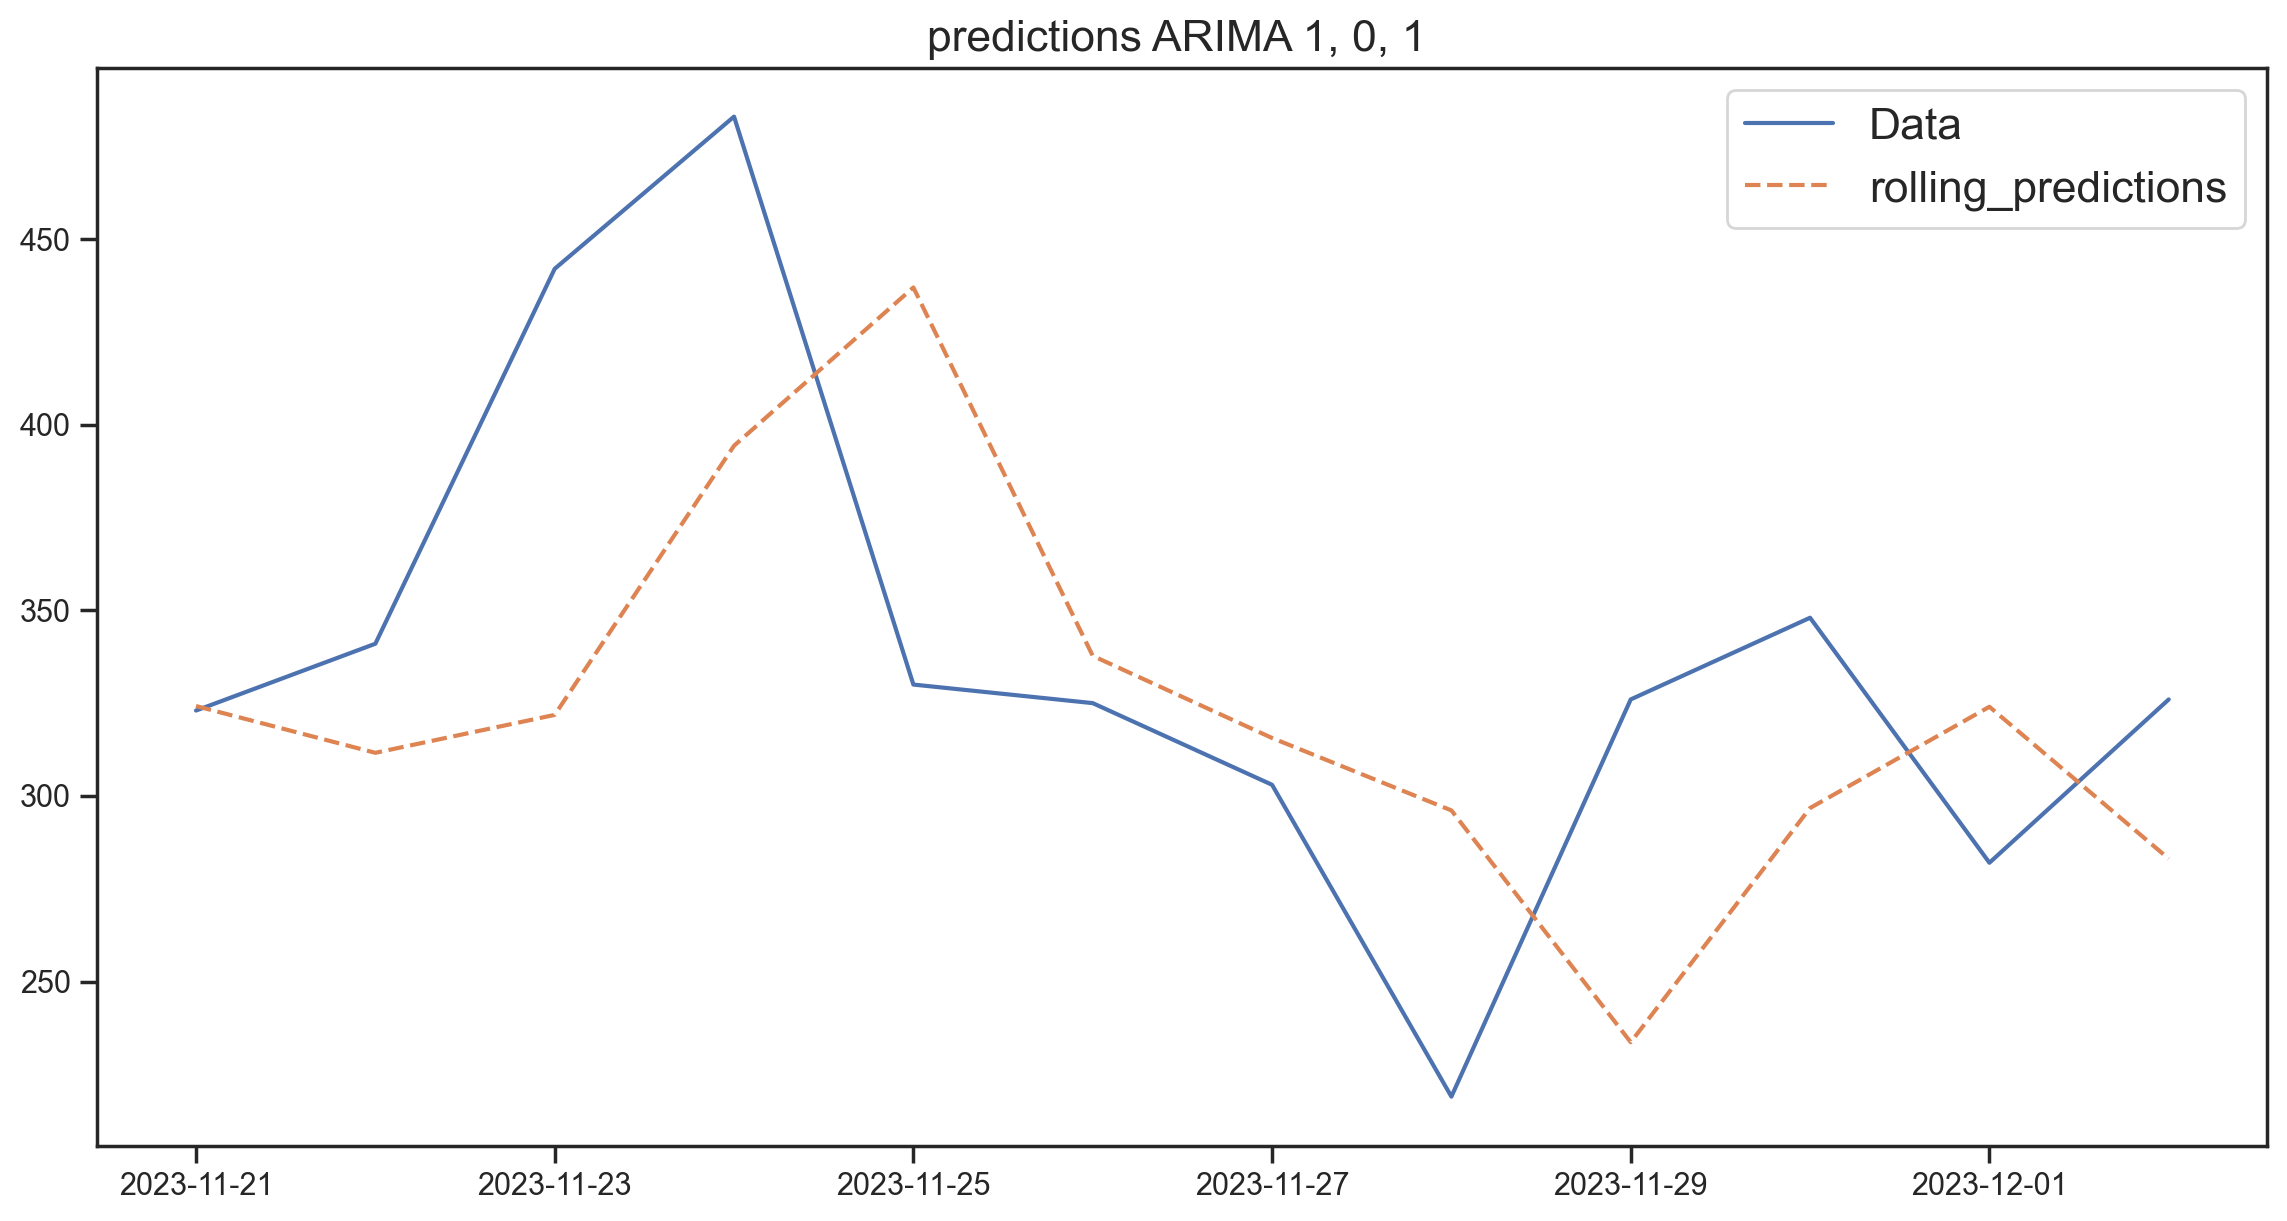

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(test_data)
plt.plot(rolling_predictions , '--')
plt.legend(('Data', 'rolling_predictions'), fontsize=16)
plt.title("predictions ARIMA {}, {}, {} ".format(p,d,q), fontsize=16)

<Figure size 1400x700 with 0 Axes>

Text(0.5, 1.0, 'Shifted -1 predictions ARIMA 1, 0, 1 ')

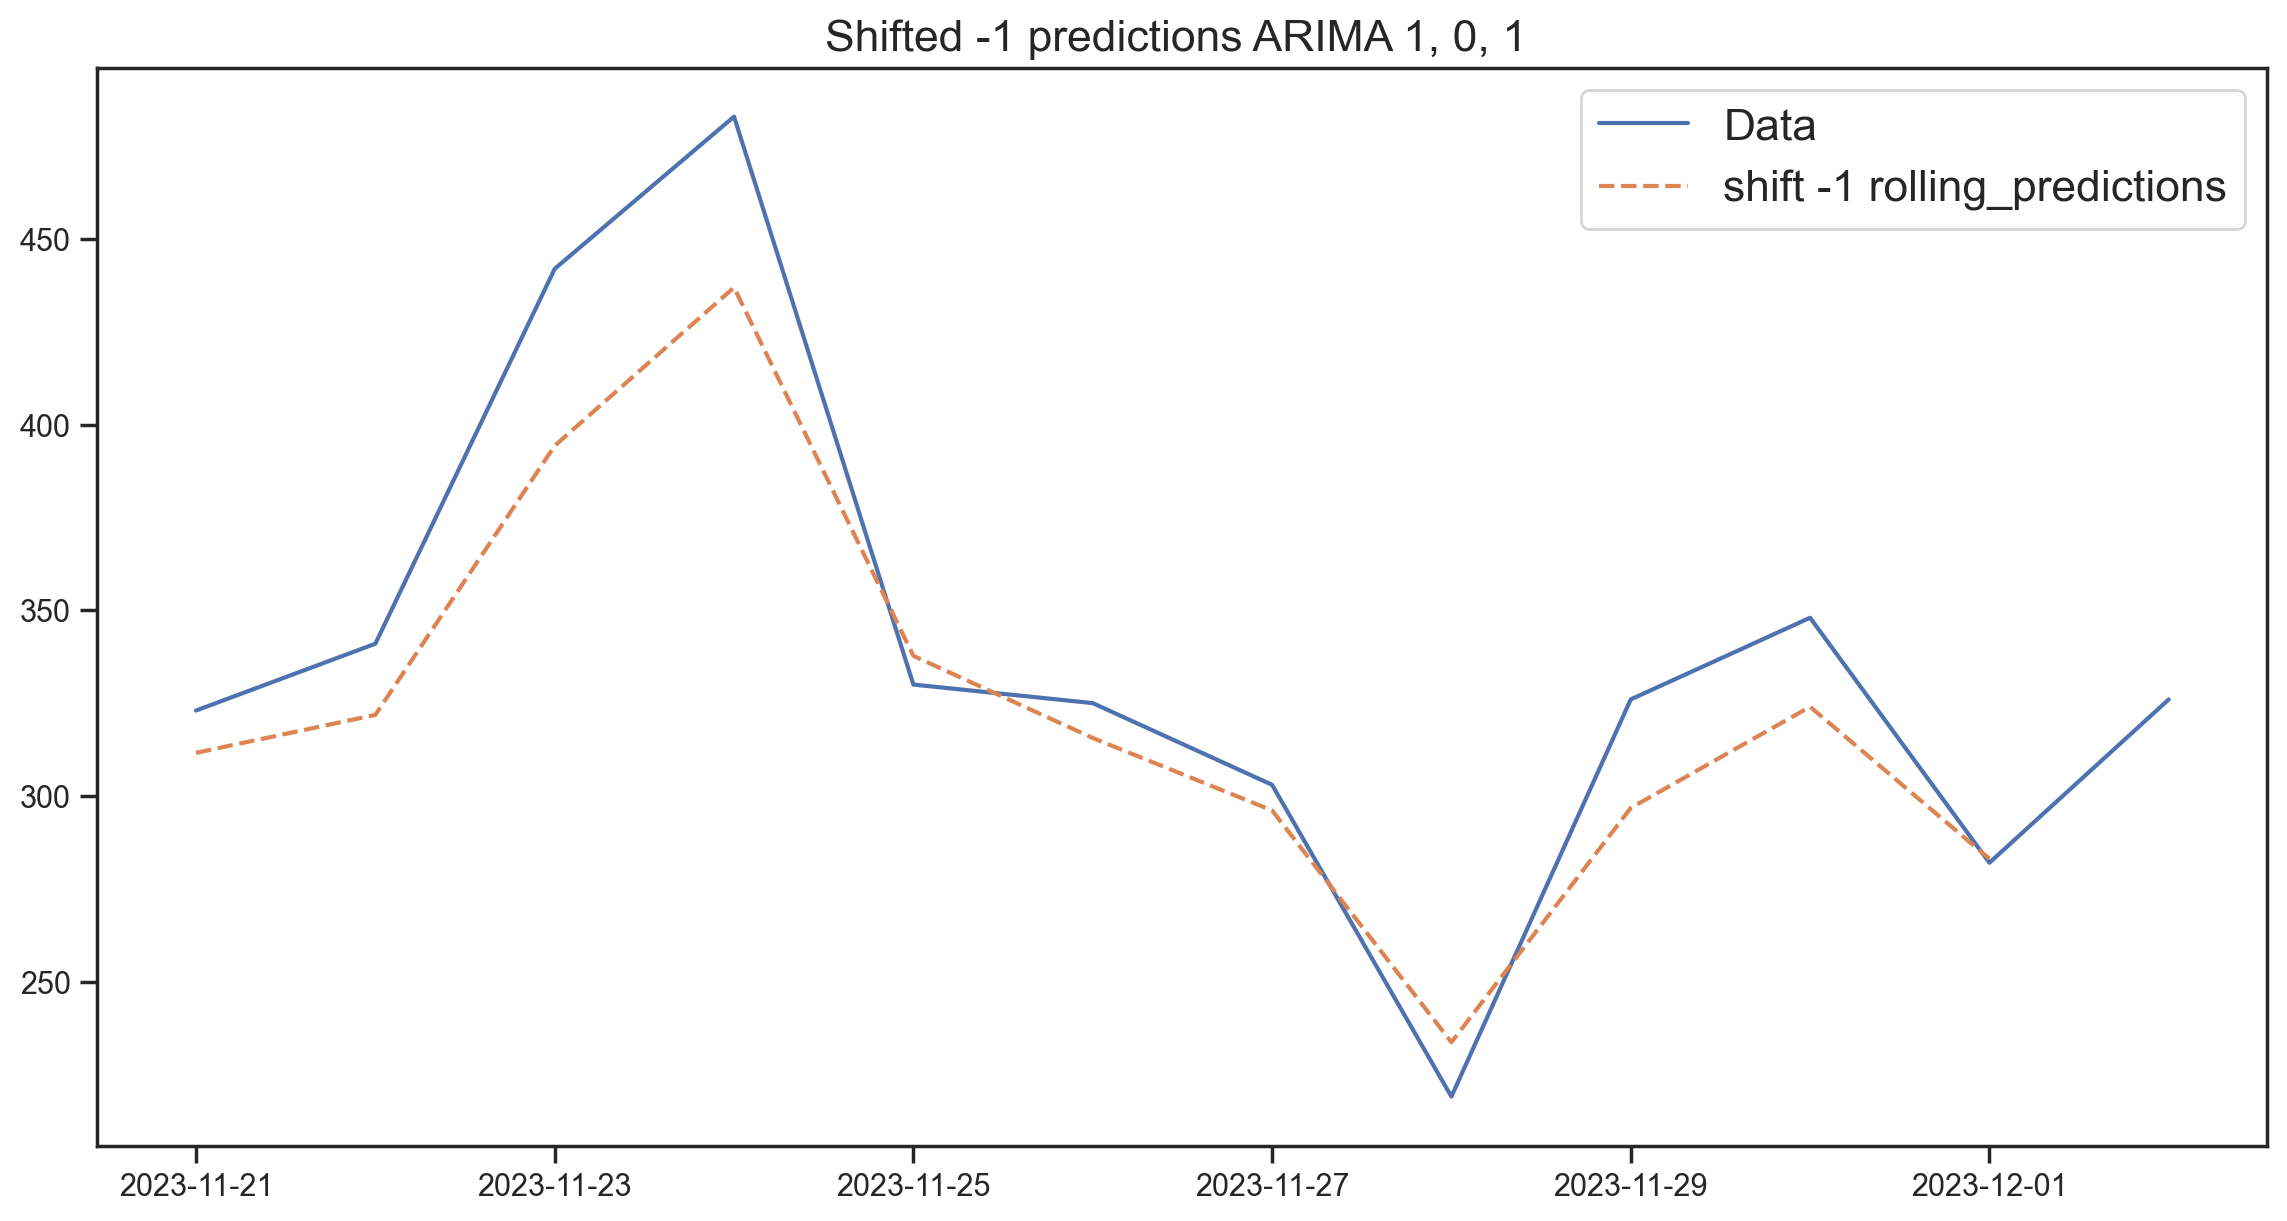

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(test_data)
plt.plot(rolling_predictions.shift(-1) , '--')
plt.legend(('Data', 'shift -1 rolling_predictions'), fontsize=16)
plt.title("Shifted -1 predictions ARIMA {}, {}, {} ".format(p,d,q), fontsize=16)

# Training without rolling ARIMA 1,0,1

In [ ]:
train_end = datetime(2023, 11, 29)
test_end = datetime(2023, 12, 2)

train_data = df[:train_end]['AQI']
test_data = df[train_end + timedelta(days=1):test_end]['AQI']

p, d, q = (1, 0, 1)
model = ARIMA(train_data, order=(p, d, q))
model_fit = model.fit()
print("Model summary ", model_fit.summary())

Model summary                                 SARIMAX Results                                
Dep. Variable:                    AQI   No. Observations:                 1365
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -7648.880
Date:                Mon, 04 Dec 2023   AIC                          15305.759
Time:                        21:55:45   BIC                          15326.635
Sample:                    03-05-2020   HQIC                         15313.573
                         - 11-29-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        222.0819     13.902     15.975      0.000     194.835     249.329
ar.L1          0.8859      0.012     71.182      0.000       0.862       0.910
ma.L1         -0.1890      0.025     

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [ ]:
#get prediction start and end dates
pred_start_date = test_data.index[0]
pred_end_date = test_data.index[-1]
pred_start_date, pred_end_date

(Timestamp('2023-11-30 00:00:00'), Timestamp('2023-12-02 00:00:00'))

In [ ]:
predictions = model_fit.predict(start=pred_start_date, end=pred_end_date, typ='levels')
residuals = test_data - predictions

In [ ]:
model_fit.forecasts[0][-10:]

array([313.51758006, 324.33013086, 311.73720045, 321.90286425,
       394.21590124, 436.45476493, 337.80222789, 315.67670744,
       296.16305538, 233.93187345])

In [ ]:
predictions

2023-11-30    296.746976
2023-12-01    288.228153
2023-12-02    280.681275
Freq: D, Name: predicted_mean, dtype: float64

In [ ]:
predictions

2023-11-30    296.746976
2023-12-01    288.228153
2023-12-02    280.681275
Freq: D, Name: predicted_mean, dtype: float64

<Figure size 1400x400 with 0 Axes>

Text(0.5, 1.0, 'Residuals from ARIMA 1, 0, 1 ')

Text(0, 0.5, 'Error')

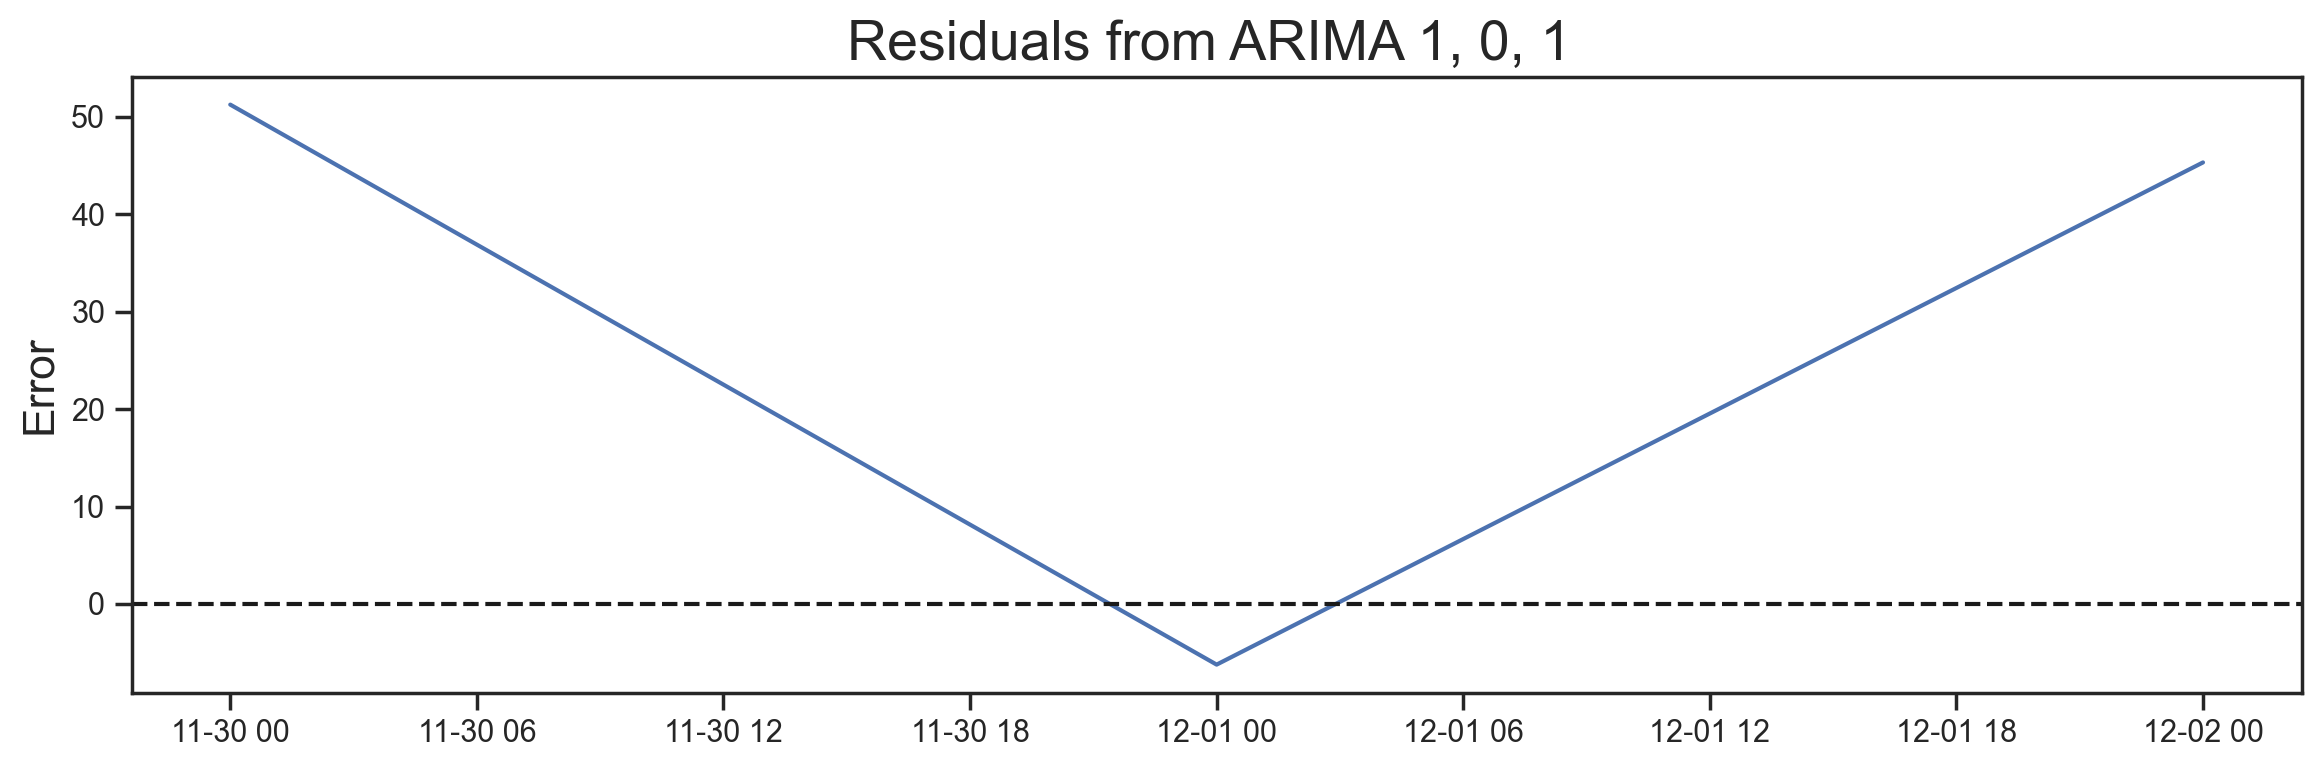

In [ ]:
plt.figure(figsize=(14,4))
plt.plot(residuals)
plt.axhline(0, linestyle='--', color='k')
plt.title('Residuals from ARIMA {}, {}, {} '.format(p,d,q), fontsize=20)
plt.ylabel('Error', fontsize=16)

<Figure size 1400x700 with 0 Axes>

Text(0.5, 1.0, 'Shifted -1 predictions ARIMA 1, 0, 1 ')

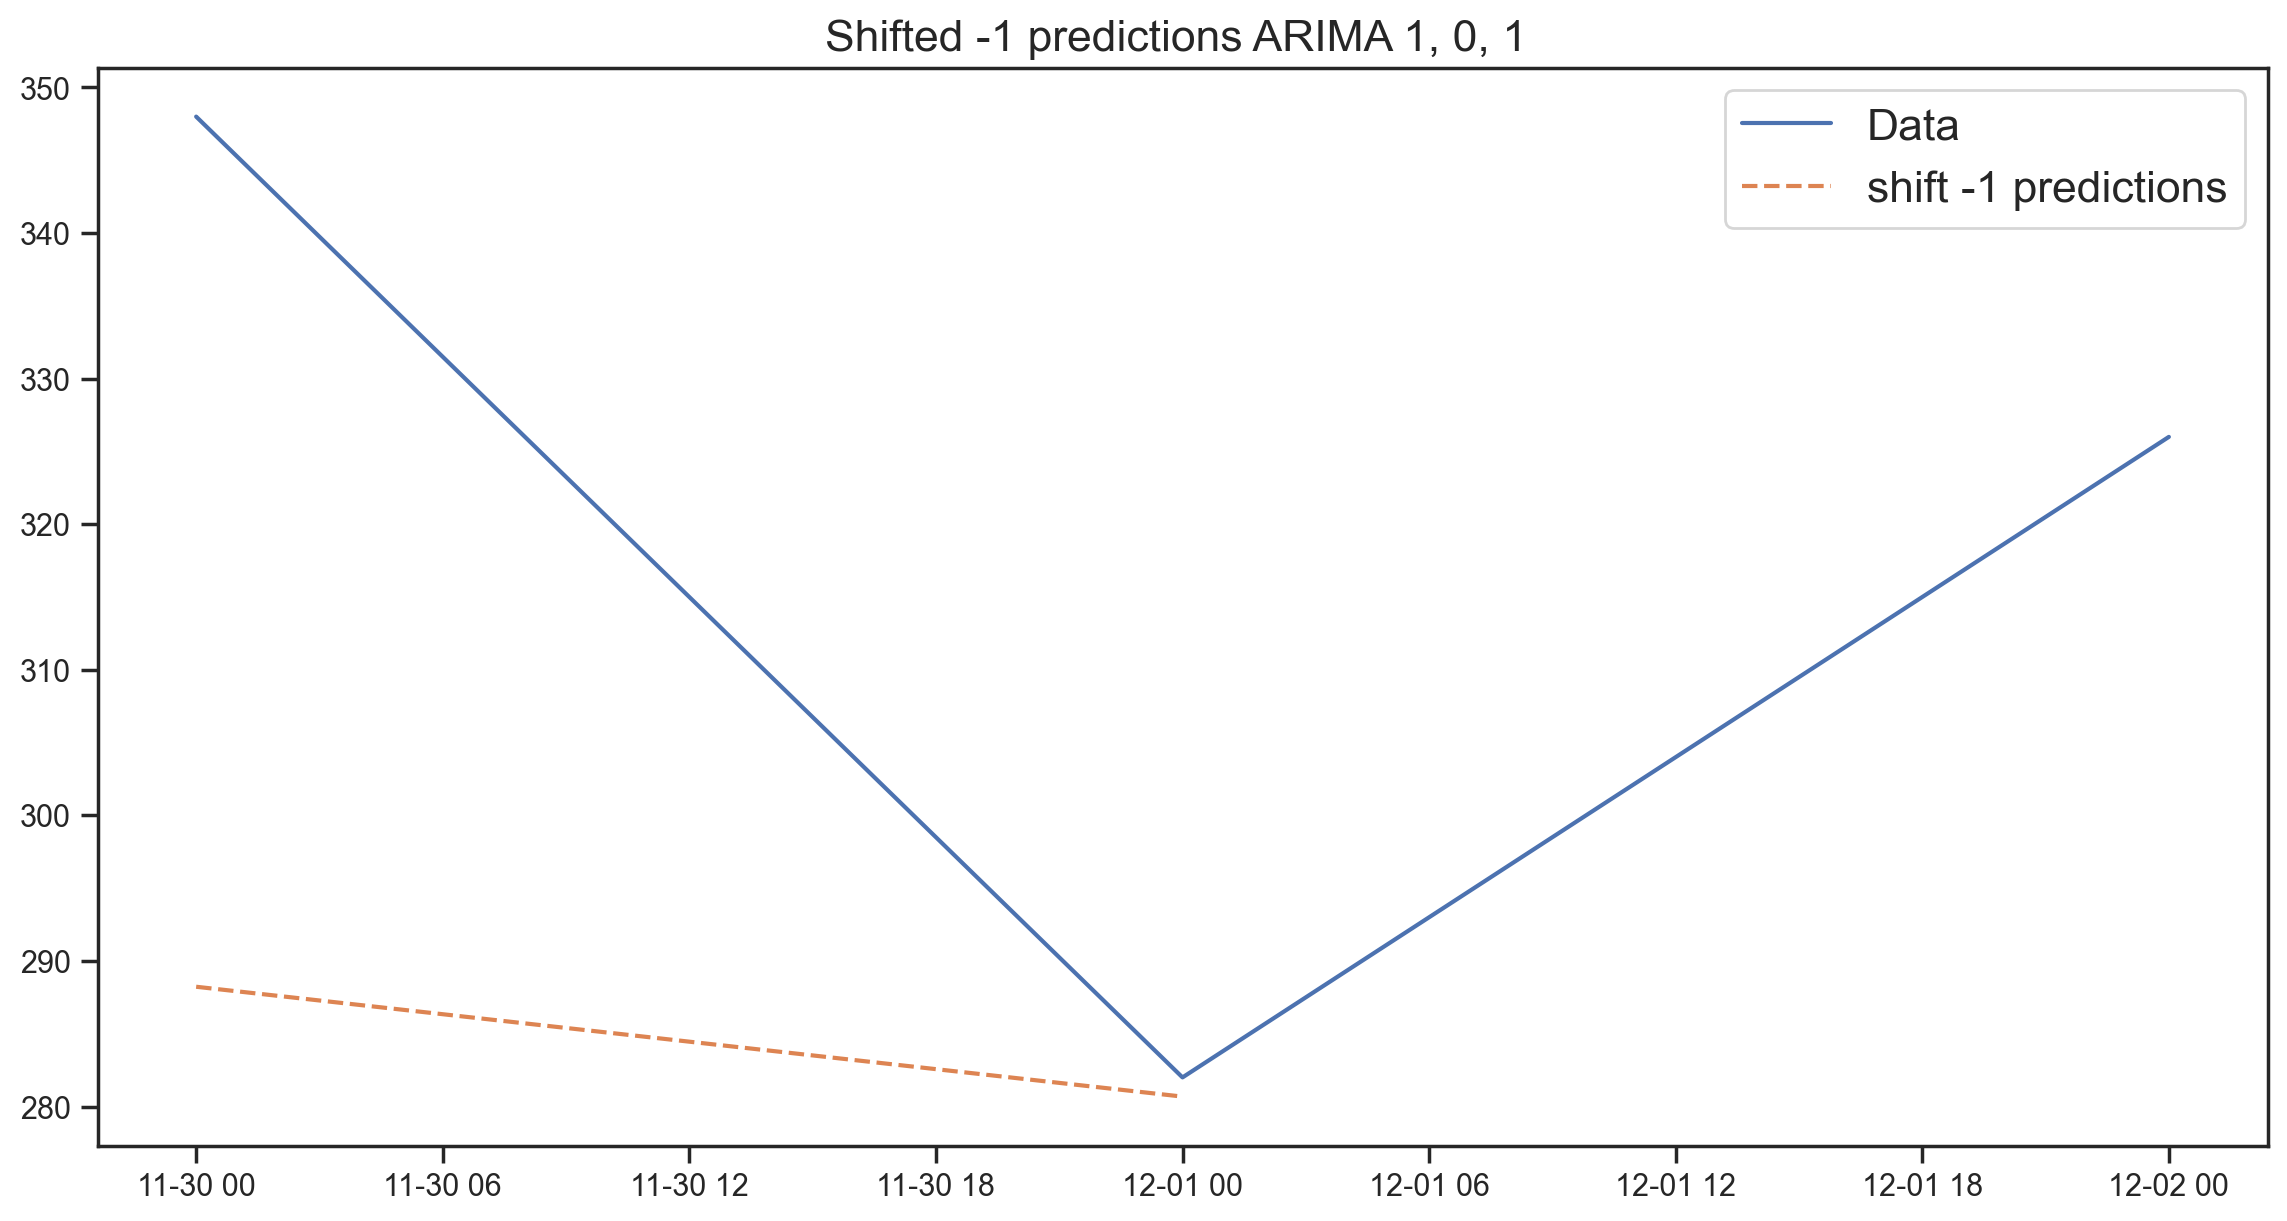

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(test_data)
plt.plot(predictions.shift(-1) , '--')
plt.legend(('Data', 'shift -1 predictions'), fontsize=16)
plt.title("Shifted -1 predictions ARIMA {}, {}, {} ".format(p,d,q), fontsize=16)

<Figure size 1400x700 with 0 Axes>

Text(0.5, 1.0, 'ARIMA 1, 0, 1')

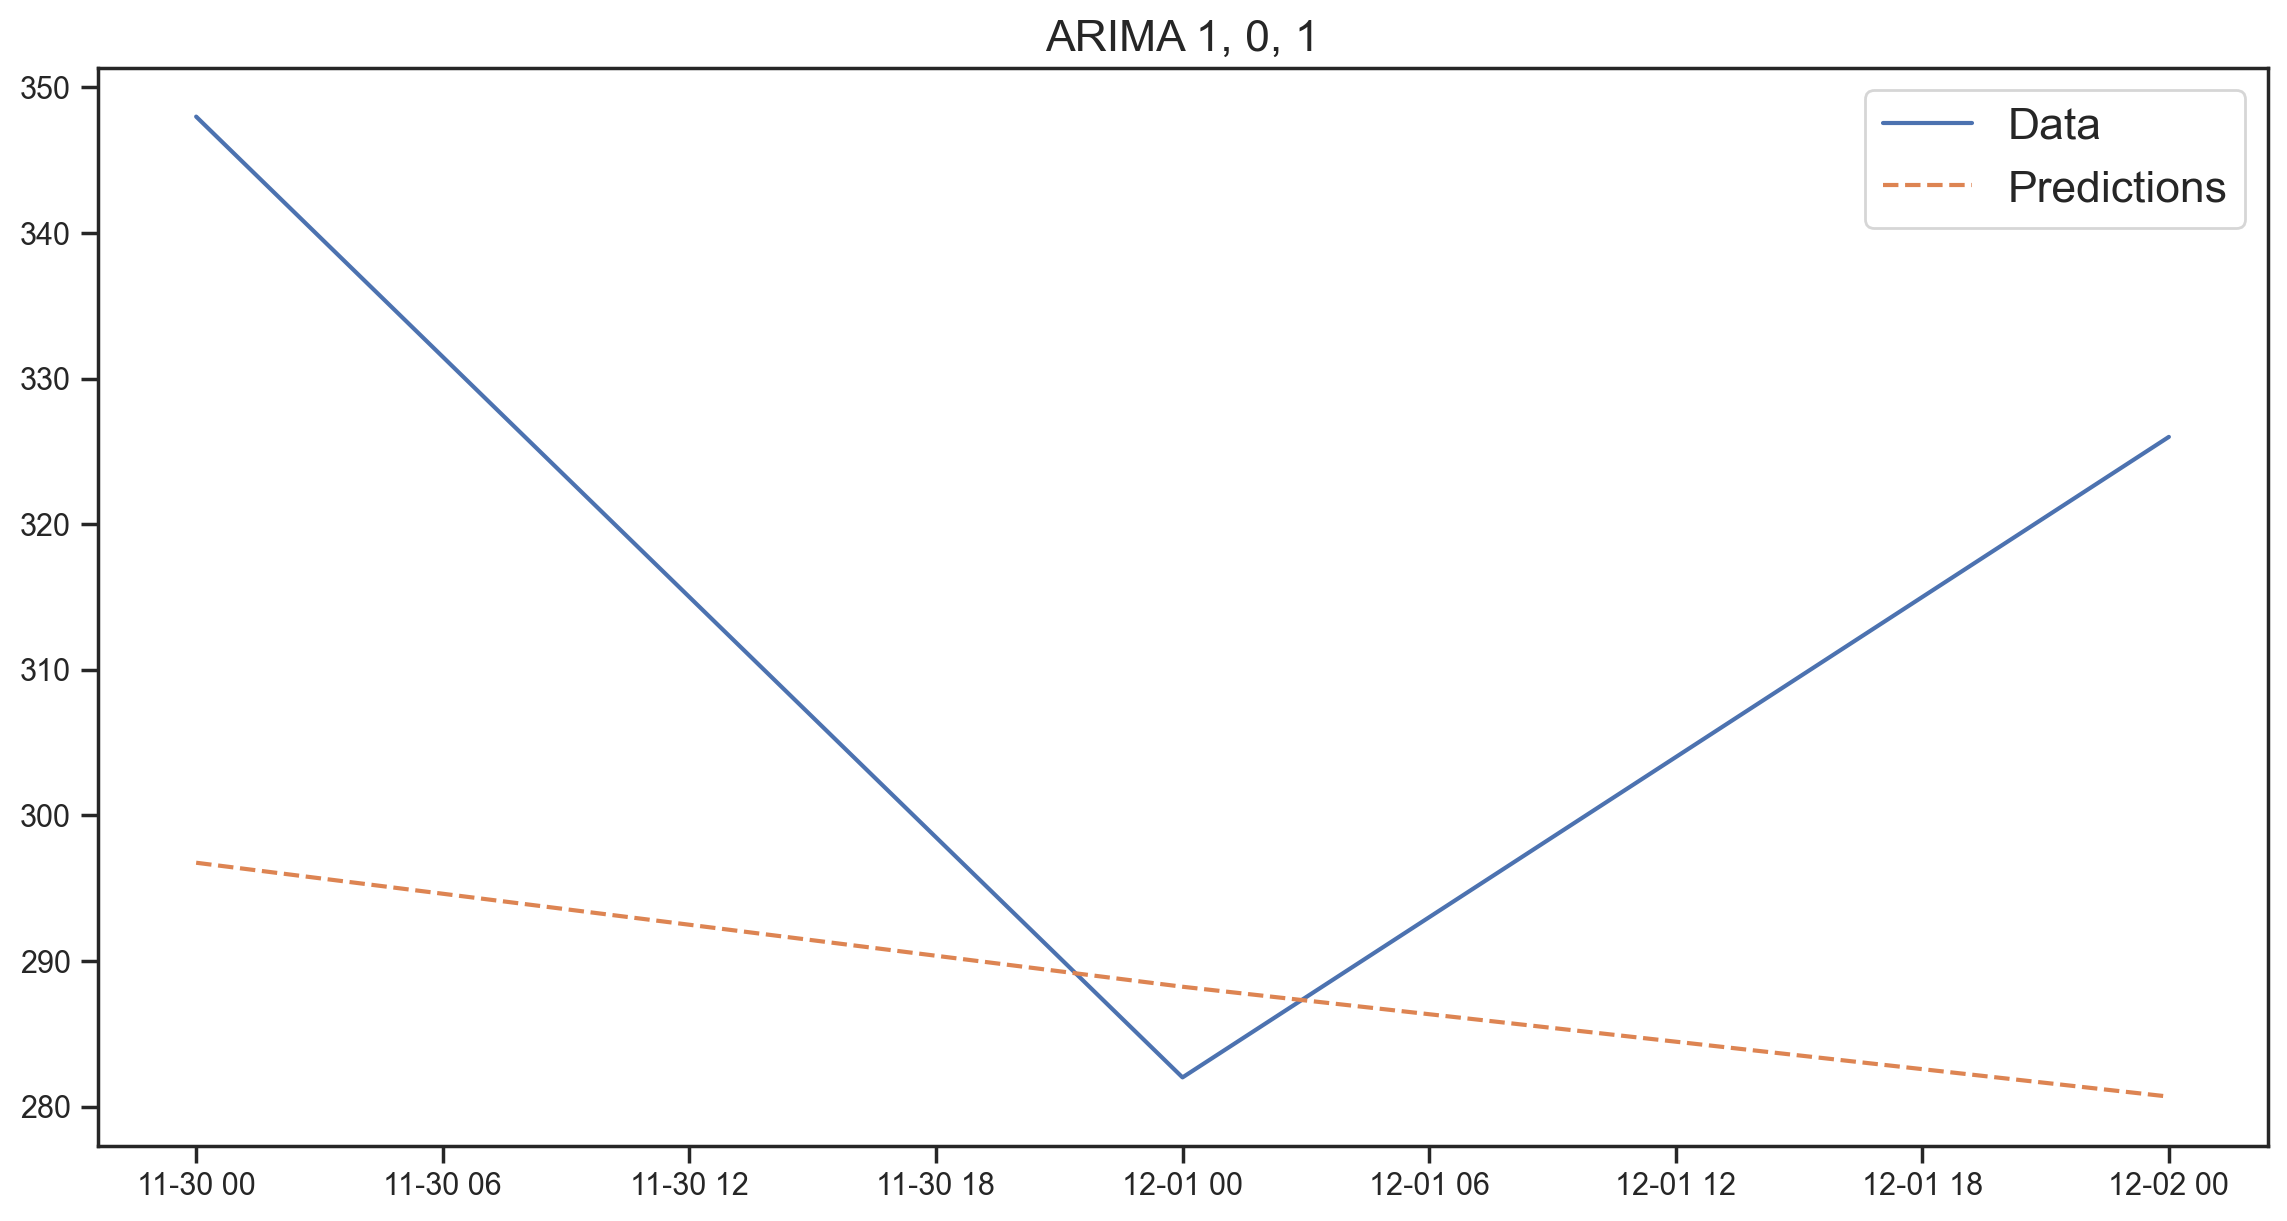

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(test_data)
plt.plot(predictions, '--')
plt.legend(('Data', 'Predictions'), fontsize=16)
plt.title("ARIMA {}, {}, {}".format(p,d,q), fontsize=16)

# Training ARIMA 1,1,1

In [ ]:
train_end = datetime(2023, 11, 26)
test_end = datetime(2023, 12, 2)

train_data = df[:train_end]['AQI']
test_data = df[train_end + timedelta(days=1):test_end]['AQI']

p, d, q = (1, 1, 1)
model = ARIMA(train_data, order=(p, d, q))
model_fit = model.fit()
print("Model summary ", model_fit.summary())

Model summary                                 SARIMAX Results                                
Dep. Variable:                    AQI   No. Observations:                 1362
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -7596.744
Date:                Mon, 04 Dec 2023   AIC                          15199.489
Time:                        21:31:43   BIC                          15215.137
Sample:                    03-05-2020   HQIC                         15205.347
                         - 11-26-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5815      0.026     22.138      0.000       0.530       0.633
ma.L1         -0.9049      0.013    -67.960      0.000      -0.931      -0.879
sigma2      4125.3413    109.596     

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [ ]:
#get prediction start and end dates
pred_start_date = test_data.index[0]
pred_end_date = test_data.index[-1]
pred_start_date, pred_end_date

(Timestamp('2023-11-27 00:00:00'), Timestamp('2023-12-02 00:00:00'))

In [ ]:
predictions = model_fit.predict(start=pred_start_date, end=pred_end_date, typ='levels')
residuals = test_data - predictions

<Figure size 1400x700 with 0 Axes>

Text(0.5, 1.0, 'ARIMA 1, 1, 1')

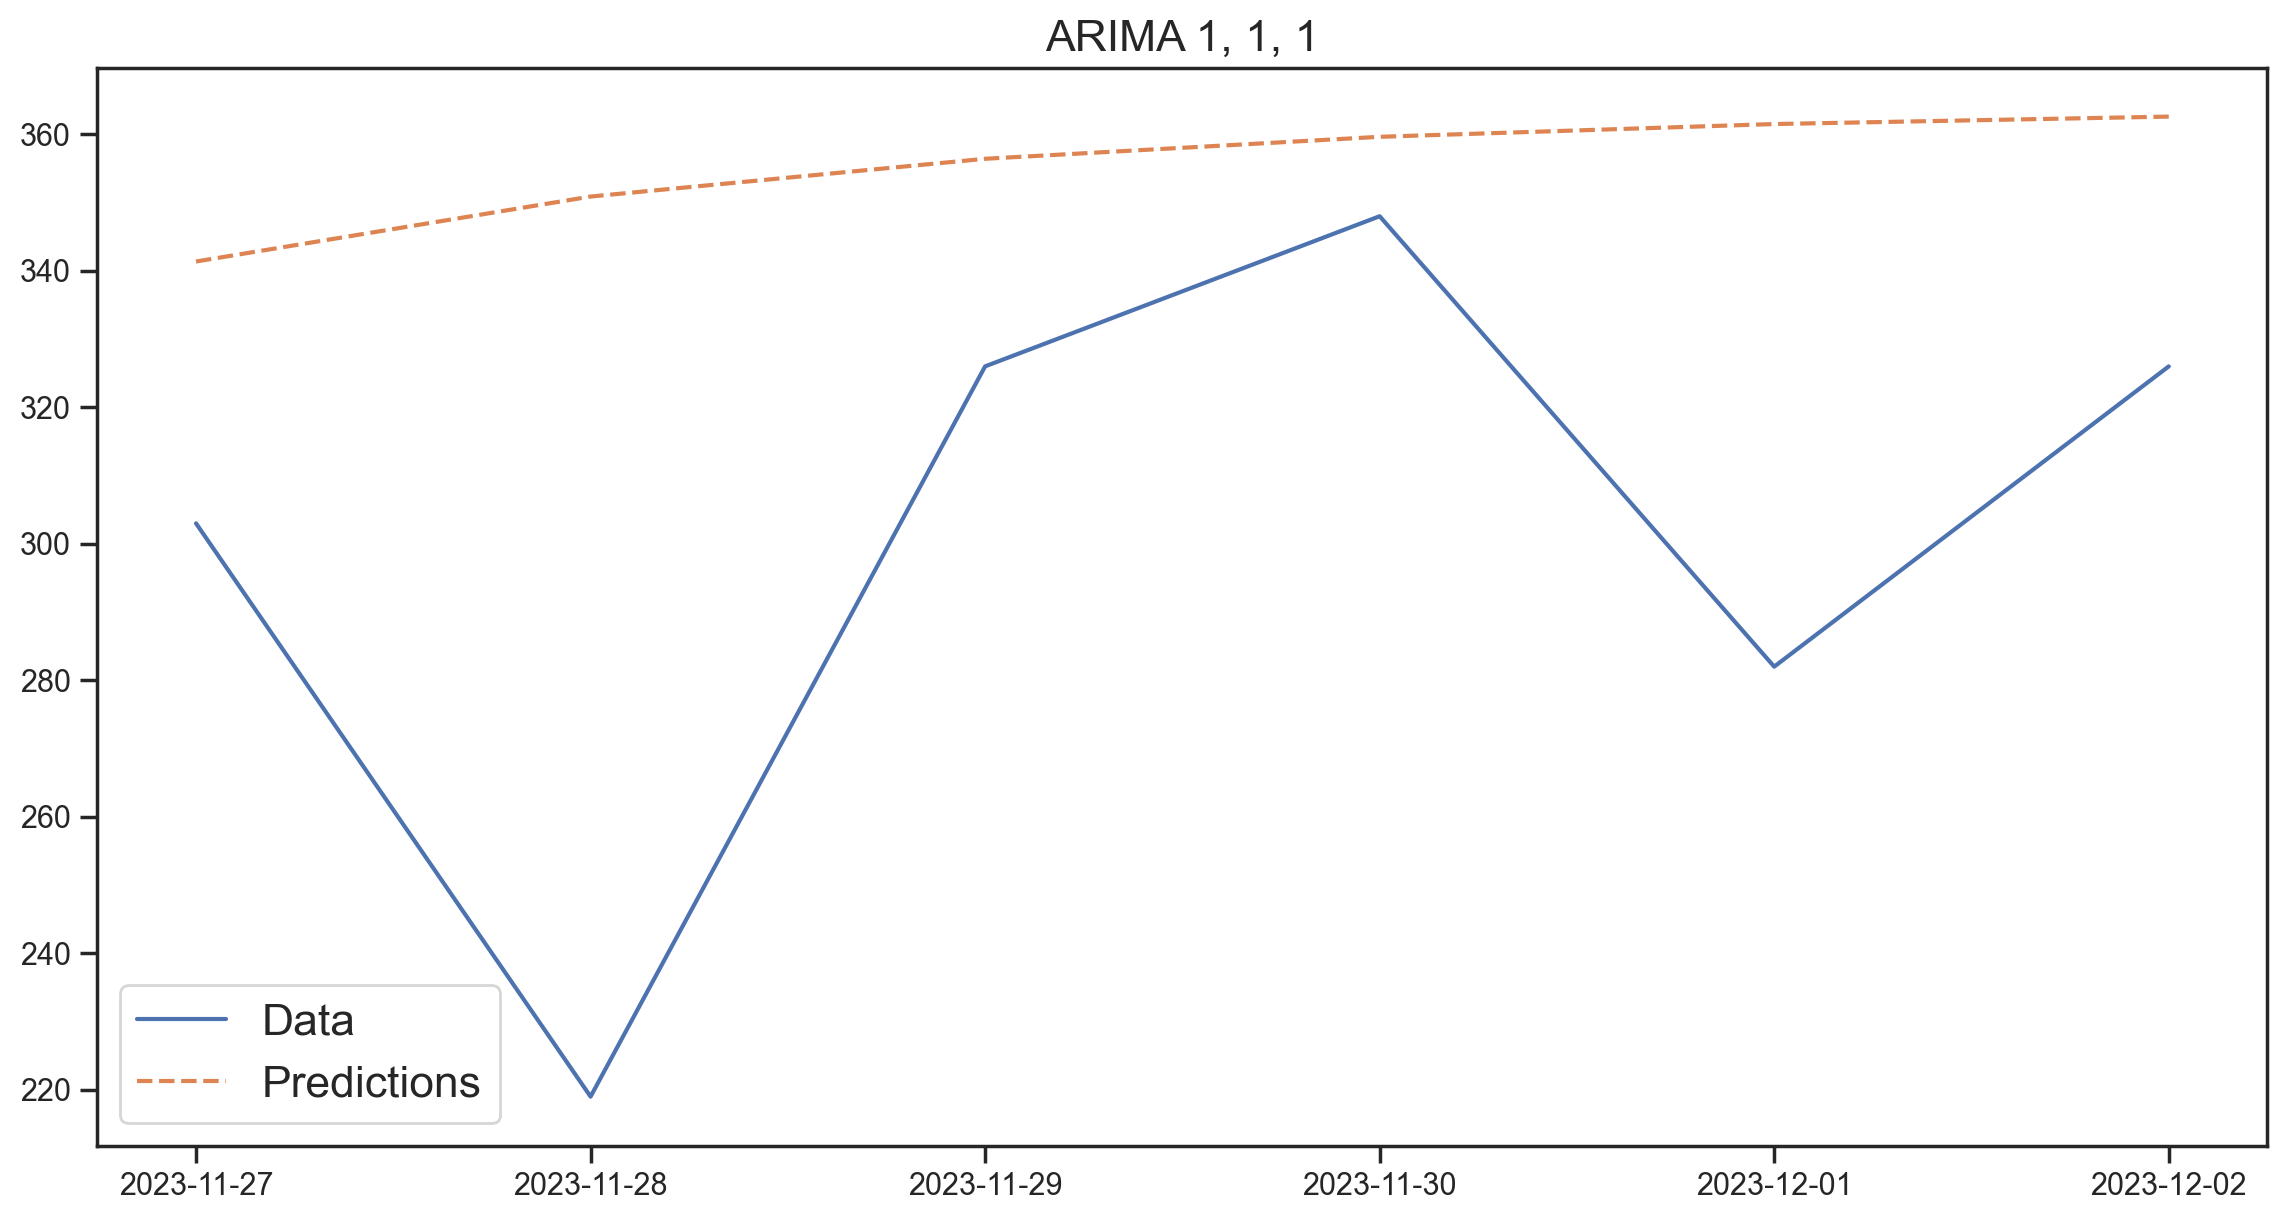

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(test_data)
plt.plot(predictions, '--')
plt.legend(('Data', 'Predictions'), fontsize=16)
plt.title("ARIMA {}, {}, {}".format(p,d,q), fontsize=16)

# SARIMAX (1, 0, 1) (1, 0, 1, 7)

In [ ]:
train_end = datetime(2023, 11, 25)
test_end = datetime(2023, 12, 2)

train_data = df[:train_end]['AQI']
test_data = df[train_end + timedelta(days=1):test_end]['AQI']

my_order = (1,0,1)
my_seasonal_order = (1, 0, 1, 7) 
# define model
model = SARIMAX(train_data, order=my_order, seasonal_order=my_seasonal_order)
model_fit = model.fit()
print("Model summary ", model_fit.summary())

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  5.70390D+00    |proj g|=  1.59741D-01

At iterate    5    f=  5.62351D+00    |proj g|=  6.81604D-04

At iterate   10    f=  5.62253D+00    |proj g|=  1.19673D-03

At iterate   15    f=  5.62172D+00    |proj g|=  1.14337D-02

At iterate   20    f=  5.61584D+00    |proj g|=  3.11932D-03

At iterate   25    f=  5.61415D+00    |proj g|=  4.30170D-03

At iterate   30    f=  5.61363D+00    |proj g|=  4.71992D-04

At iterate   35    f=  5.61350D+00    |proj g|=  1.19217D-03

At iterate   40    f=  5.61341D+00    |proj g|=  5.41876D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg 

In [ ]:
predictions = model_fit.forecast(len(test_data))
predictions = pd.Series(predictions, index=test_data.index)
residuals = test_data - predictions
residuals

Date
2023-11-26    -6.888257
2023-11-27   -20.281869
2023-11-28   -98.231032
2023-11-29    21.897186
2023-11-30    46.876320
2023-12-01   -14.520634
2023-12-02    42.310683
dtype: float64

<Figure size 1400x700 with 0 Axes>

Text(0.5, 1.0, 'alandur AQI daily SARIMAX(1, 0, 1)(1, 0, 1, 7)')

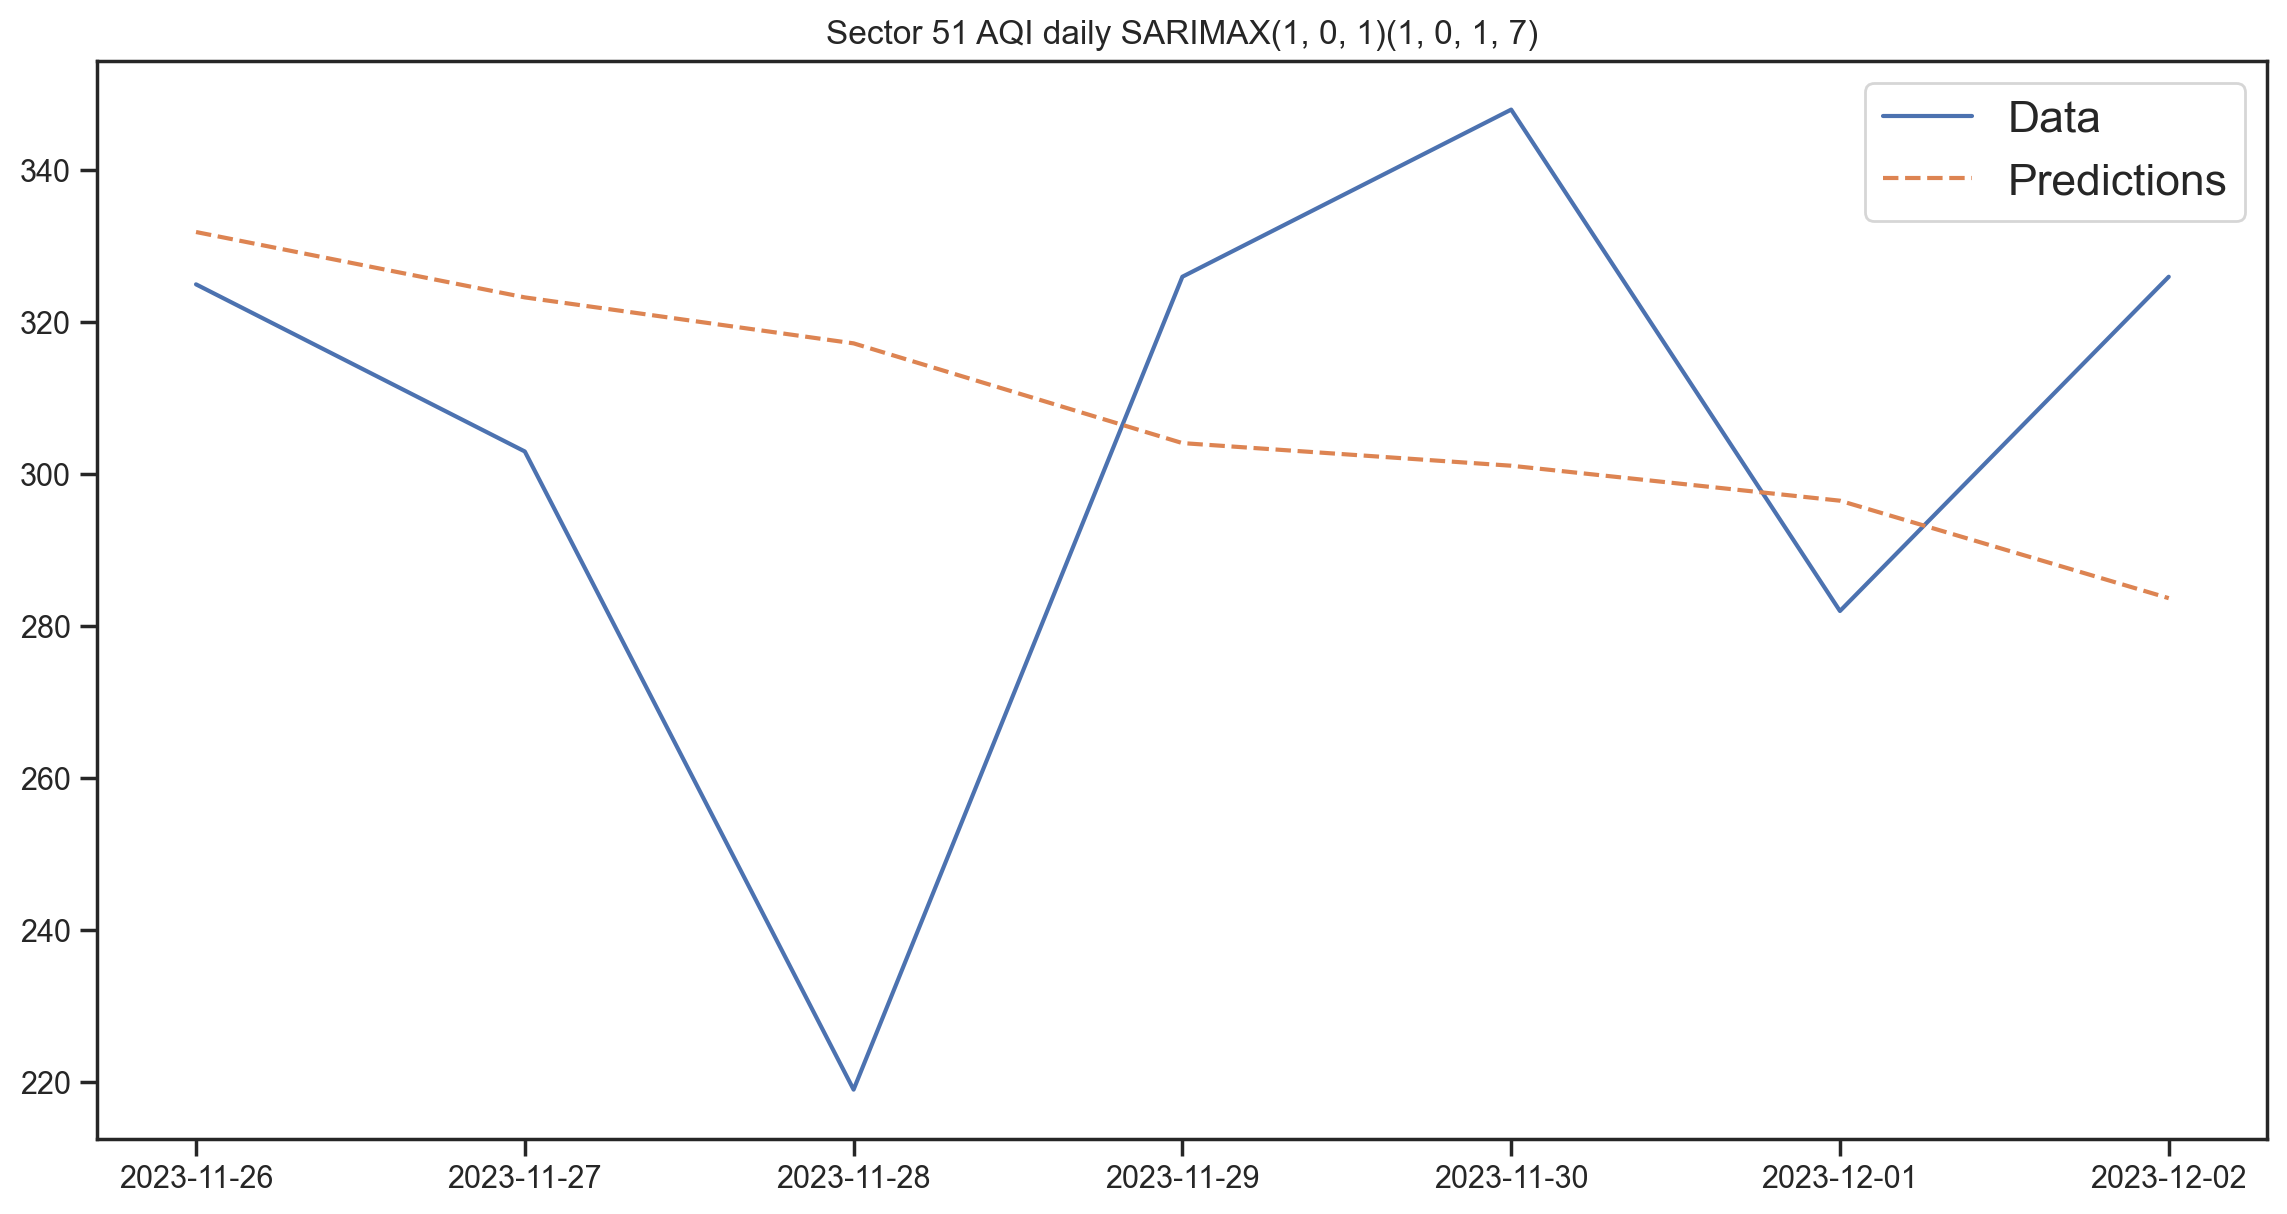

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(test_data)
plt.plot(predictions, '--')
plt.legend(('Data', 'Predictions'), fontsize=16)
plt.title("alandur AQI daily SARIMAX" + str(my_order) + str(my_seasonal_order) )

In [ ]:
np.sqrt(np.sum((test_data - predictions)**2)/len(test_data))

45.959697801564786

In [ ]:
(np.sum(abs(test_data - predictions))/len(test_data))

35.857997299410115

In [ ]:
model_fit.aic 

15289.709950194389

# SARIMAX 

In [ ]:
train_end = datetime(2023, 11, 25)
test_end = datetime(2023, 12, 2)

train_data = df[:train_end]['AQI']
test_data = df[train_end + timedelta(days=1):test_end]['AQI']

my_order = (1,0,1)
my_seasonal_order = (1, 0, 1, 24) 
# define model
model = SARIMAX(train_data, order=my_order, seasonal_order=my_seasonal_order)
model_fit = model.fit()
print("Model summary ", model_fit.summary())

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  5.67506D+00    |proj g|=  1.16045D-01

At iterate    5    f=  5.62230D+00    |proj g|=  7.18510D-04

At iterate   10    f=  5.62198D+00    |proj g|=  1.16179D-03

At iterate   15    f=  5.62196D+00    |proj g|=  9.86485D-04

At iterate   20    f=  5.62195D+00    |proj g|=  3.35362D-05

At iterate   25    f=  5.62188D+00    |proj g|=  7.93657D-04

At iterate   30    f=  5.62110D+00    |proj g|=  3.05506D-03

At iterate   35    f=  5.62050D+00    |proj g|=  1.24327D-03

At iterate   40    f=  5.61966D+00    |proj g|=  5.01061D-03

At iterate   45    f=  5.61945D+00    |proj g|=  3.99155D-04
  ys=-1.135E-05  -gs= 1.002E-05 BFGS update SKIPPED

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy search


   evaluations in the last line search.  Termination
   may possibly be caused by a bad search direction.


Model summary                                       SARIMAX Results                                      
Dep. Variable:                                AQI   No. Observations:                 1361
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 24)   Log Likelihood               -7648.068
Date:                            Tue, 05 Dec 2023   AIC                          15306.136
Time:                                    17:18:10   BIC                          15332.216
Sample:                                03-05-2020   HQIC                         15315.899
                                     - 11-25-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9447      0.008    112.441      0.000       0.928       0.961
ma.L1         -0.248

In [ ]:
predictions = model_fit.forecast(len(test_data))
predictions = pd.Series(predictions, index=test_data.index)
residuals = test_data - predictions
residuals

Date
2023-11-26    -15.396584
2023-11-27    -33.075112
2023-11-28   -114.645057
2023-11-29      7.041115
2023-11-30     29.950936
2023-12-01    -25.228513
2023-12-02     27.035766
dtype: float64

<Figure size 1400x700 with 0 Axes>

Text(0.5, 1.0, 'alandur AQI daily SARIMAX(1, 0, 1)(1, 0, 1, 24)')

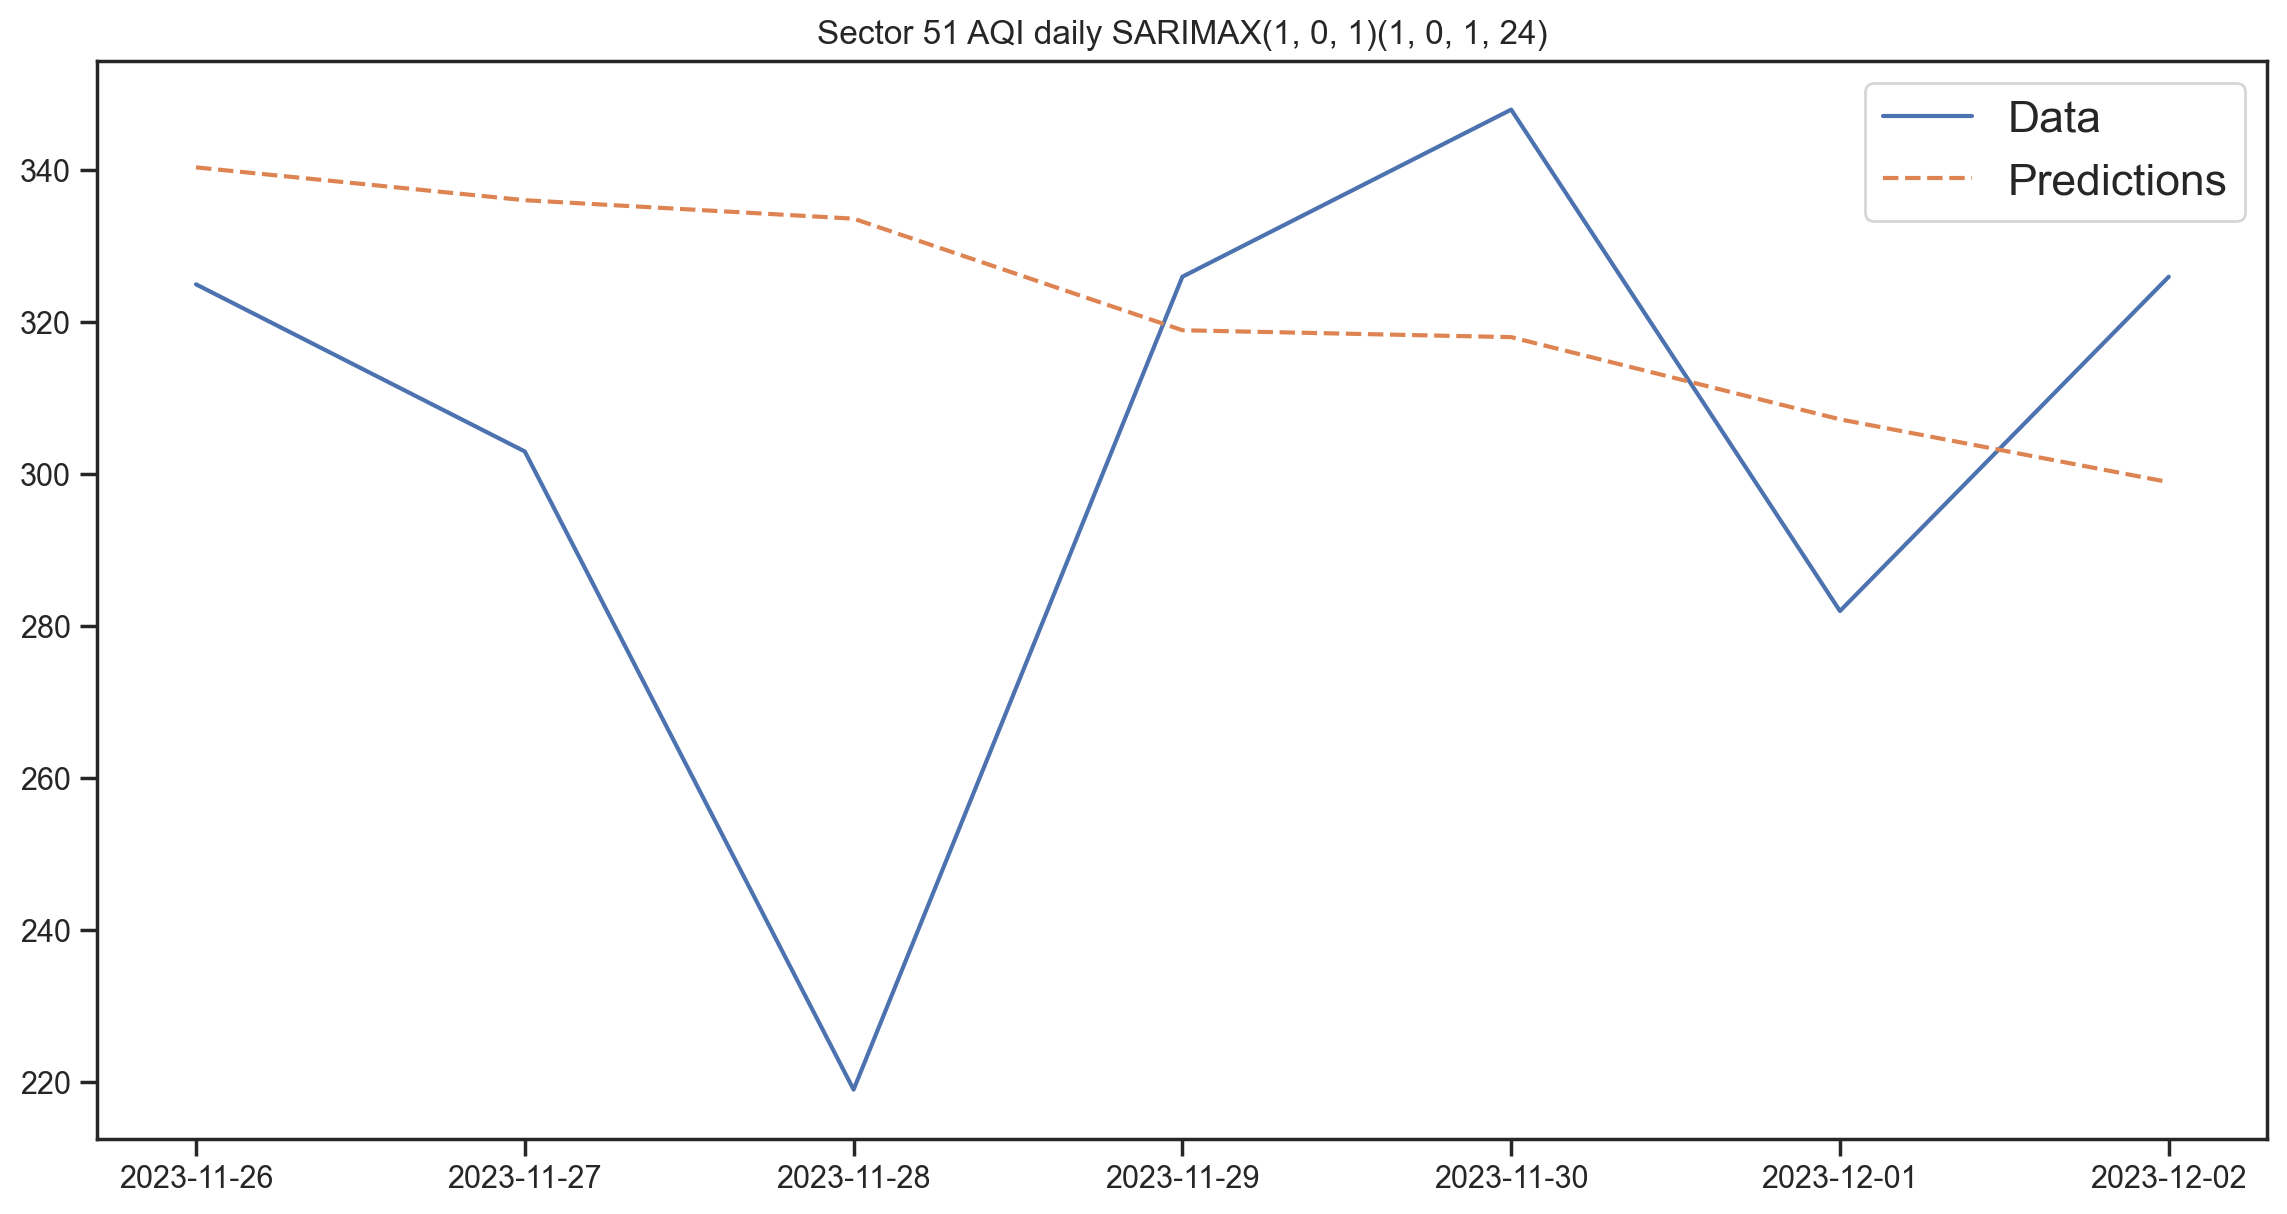

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(test_data)
plt.plot(predictions, '--')
plt.legend(('Data', 'Predictions'), fontsize=16)
plt.title("alandur AQI daily SARIMAX" + str(my_order) + str(my_seasonal_order) )

In [ ]:
(np.sum(abs(test_data - predictions))/len(test_data)) # "MAE_(1,0,1), (1,0,1,6)" = 35.77

35.77868282189337

In [ ]:
(np.sum(abs(test_data - predictions))/len(test_data))  # "MAE_(1,0,1), (1,0,1,7)" = 36.05

36.053297661697066

In [ ]:
model_fit.aic 

15306.135923799113

In [ ]:
results

,p,d,q,MSE,Rolling?,AIC
0,1,0,1,16.803441,True,15327.189958
